Data Mining & Machine Learning

M.Sc. in Artificial Intelligence and Data Engineering

University of Pisa

Authors

Elia Marabotto - 615689

Luca Minuti - 635317

## INDEX

*   [DATA LOADING](#scrollTo=LGQfDHweFEuw)
*   [MISSING VALUES CHECK](#scrollTo=WPZQ8TVMidWe)
*   [START OF EXPLORATORY DATA ANALYSIS](#scrollTo=HFtrosaRjnMT)
*   [VARIABLE DISTRIBUTIONS, BOXPLOTS AND OUTLIER DETECTION](#scrollTo=OoQMh8kwiM0s)
*   [FEATURE CORRELATION](#scrollTo=No4-QpjLlzT8)
*   [CORRELATION WITH THE TARGET VARIABLE](#scrollTo=WdNdhzw2o6j3)
*   [GLOBAL DATA PREPROCESSING](#scrollTo=AY4RlDgd2Mfo)
*   [TARGET ISOLATION & GROUP DEFINITION](#scrollTo=lc655bTCL8nk)
*   [MODEL TRAINING PHASE (RANDOM FOREST)](#scrollTo=l1tqganTUGzK)
*   [MODEL TRAINING PHASE (ADABOOST)](#scrollTo=jt58ejQsVoho)
*   [MODEL TRAINING PHASE (XGBOOST)](#scrollTo=KNfs7M8V4mvX)
*   [MODEL TRAINING PHASE (NAIVE BAYES)](#scrollTo=QxZiRbCfsBS4)
*   [MODEL TRAINING PHASE (LOGISTIC REGRESSION)](#scrollTo=R4T7JRWnhbAE)
*   [MODELS' COMPARISON](#scrollTo=C9FPnPXemgqJ)
*   [FINAL MODEL TUNING AND TRAINING](#scrollTo=mtVWFkj6J0dt)
*   [XAI](#scrollTo=hVQrh177PHio)


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import io
import requests
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from google.colab import files
from scipy.stats import wilcoxon
from sklearn.metrics import precision_score, recall_score
from tqdm.notebook import tqdm
from pathlib import Path

In [ ]:
# --- CHECKPOINT SETUP ---
from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = Path('/content/drive/MyDrive/checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f"Checkpoint directory ready: {CHECKPOINT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint directory ready: /content/drive/MyDrive/checkpoints


<span id='LGQfDHweFEuw'></span>
#DATA LOADING

In [2]:
#Loading of the dataset
username = "LucaMinuti"
repo = "DiabetesCheck"
path_to_file = "dataset/diabetes_012_health_indicators_BRFSS2015.csv"

url = f"https://raw.githubusercontent.com/{username}/{repo}/main/{path_to_file}"

df = pd.read_csv(url, sep=';')

print("Dataset Loaded!")
print(f"Dimensions of the dataset: {df.shape}")
df.head()

Dataset Loaded!
Dimensions of the dataset: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# This line instructs Pandas to never cut text in columns
pd.set_option('display.max_colwidth', None)

# Creating the dictionary with the legend data
data_legend = {
    'Variable': [
        'Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
        'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits',
        'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
        'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income'
    ],
    'Description': [
        'Patient status (Target)', 'High Blood Pressure diagnosed', 'High Cholesterol diagnosed',
        'Cholesterol check (last 5 years)', 'Body Mass Index', 'Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes]',
        '(Ever told) you had a stroke.', 'coronary heart disease (CHD) or myocardial infarction (MI)', 'physical activity in past 30 days - not including job',
        'Consume Fruit 1 or more times per day', 'Consume Vegetables 1 or more times per day', 'Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week)',
        'Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc.', 'Was there a time in the past 12 months when you needed to see a doctor but could not because of cost?',
        'Would you say that in general your health is',
        'Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days',
        'Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? ',
        'Do you have serious difficulty walking or climbing stairs?',
        'Sex', "13-level age category", 'Education level', 'Income scale'
    ],
    'Values / Encoding': [
        '0 = no diabetes 1 = prediabetes 2 = diabetes', '0 = no high BP 1 = high BP', '0 = no high cholesterol 1 = high cholesterol',
        '0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years', 'Continuous values (eg. 12-98)', '0: No, 1: Yes',
        '0: No, 1: Yes', '0: No, 1: Yes', '0: No, 1: Yes',
        '0: No, 1: Yes', '0: No, 1: Yes', '0: No, 1: Yes',
        '0: No, 1: Yes', '0: No, 1: Yes', '1 = excellent 2 = very good 3 = good 4 = fair 5 = poor',
        '0 - 30 days', '0 - 30 days', '0: No, 1: Yes', '0 = female 1 = male',
        '1 = 18-24 9 = 60-64 13 = 80 or older', '1 = Never attended school or only kindergarten 2 = Grades 1 through 8 (Elementary)', '1 = less than $10,000 5 = less than $35,000 8 = $75,000 or more'
    ]
}

# Creating the DataFrame
df_legend = pd.DataFrame(data_legend)

# Apply the style to align the text to the left
df_styled = df_legend.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    dict(selector='th', props=[('text-align', 'left')])
])

# Display the stylized table
df_styled



,Variable,Description,Values / Encoding
0,Diabetes_012,Patient status (Target),0 = no diabetes 1 = prediabetes 2 = diabetes
1,HighBP,High Blood Pressure diagnosed,0 = no high BP 1 = high BP
2,HighChol,High Cholesterol diagnosed,0 = no high cholesterol 1 = high cholesterol
3,CholCheck,Cholesterol check (last 5 years),0 = no cholesterol check in 5 years 1 = yes cholesterol check in 5 years
4,BMI,Body Mass Index,Continuous values (eg. 12-98)
5,Smoker,Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes],"0: No, 1: Yes"
6,Stroke,(Ever told) you had a stroke.,"0: No, 1: Yes"
7,HeartDiseaseorAttack,coronary heart disease (CHD) or myocardial infarction (MI),"0: No, 1: Yes"
8,PhysActivity,physical activity in past 30 days - not including job,"0: No, 1: Yes"
9,Fruits,Consume Fruit 1 or more times per day,"0: No, 1: Yes"


<span id='WPZQ8TVMidWe'></span>
#MISSING VALUES CHECK

In [ ]:
# --- Basic Data Integrity Check ---
# Checking for missing values
null_counts = df.isnull().sum()
print("\n" + "="*50)
print("--- Missing Values Analysis ---")
print("="*50)
if null_counts.any():
    print(null_counts[null_counts > 0])
else:
    print("No missing values detected. The dataset is complete.")

# Quick check on data types
print("\n--- Data Types Overview ---")
print(df.dtypes.value_counts())



--- Missing Values Analysis ---
No missing values detected. The dataset is complete.

--- Data Types Overview ---
float64    22
Name: count, dtype: int64


<span id='HFtrosaRjnMT'></span>
#START OF EXPLORATORY DATA ANALYSIS

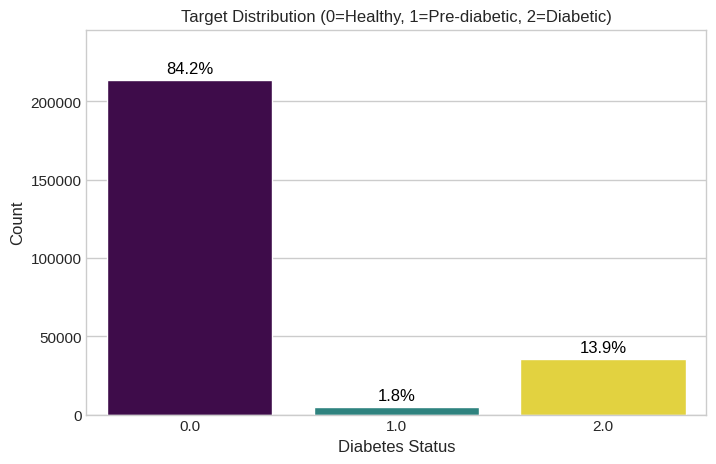

In [ ]:
# --- 1. Target Class Distribution Analysis ---
# We use a countplot to visualize the imbalance between classes.
# Class 1 (Pre-diabetes) is expected to be significantly underrepresented.

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Diabetes_012', data=df, hue='Diabetes_012', palette='viridis', legend=False)

# Percentage calculation
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

ax.set_ylim(0, df['Diabetes_012'].value_counts().max() * 1.15)

plt.title('Target Distribution (0=Healthy, 1=Pre-diabetic, 2=Diabetic)')
plt.xlabel('Diabetes Status')
plt.ylabel('Count')
plt.show()


<span id='OoQMh8kwiM0s'></span>
#VARIABLE DISTRIBUTIONS, BOXPLOTS AND OUTLIER DETECTION

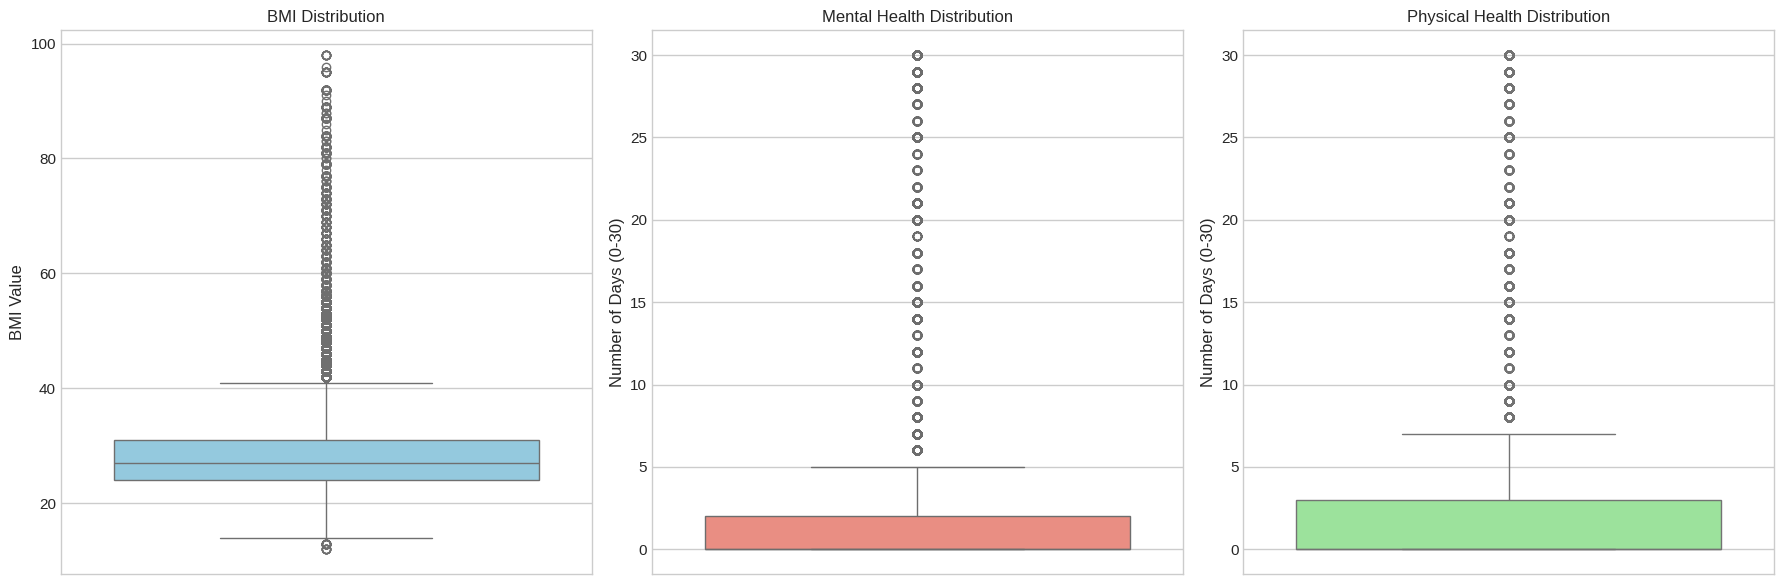

--- Data Integrity Check ---
BMI range: 12.0 to 98.0
Mental Health range (Days): 0.0 to 30.0
Physical Health range (Days): 0.0 to 30.0
Number of invalid records (>30 days): 0


In [ ]:
# --- Outlier Detection and Visualization ---
# We focus on continuous/ordinal variables where outliers or
# illogical values are most likely to occur: BMI, MentHlth, and PhysHlth.

# Setting up the figure for a 1x3 grid of boxplots
plt.figure(figsize=(18, 6))

# 1. BMI Boxplot
# Looking for physiologically impossible values
plt.subplot(1, 3, 1)
sns.boxplot(y=df['BMI'], color='skyblue')
plt.title('BMI Distribution')
plt.ylabel('BMI Value')

# 2. Mental Health Boxplot
# Values must be between 0 and 30 days
plt.subplot(1, 3, 2)
sns.boxplot(y=df['MentHlth'], color='salmon')
plt.title('Mental Health Distribution')
plt.ylabel('Number of Days (0-30)')

# 3. Physical Health Boxplot
# Values must be between 0 and 30 days
plt.subplot(1, 3, 3)
sns.boxplot(y=df['PhysHlth'], color='lightgreen')
plt.title('Physical Health Distribution')
plt.ylabel('Number of Days (0-30)')

plt.tight_layout()
plt.show()

# --- Logical Consistency Check ---
# Printing range statistics to verify if data stays within expected bounds.
print("--- Data Integrity Check ---")
print(f"BMI range: {df['BMI'].min()} to {df['BMI'].max()}")
print(f"Mental Health range (Days): {df['MentHlth'].min()} to {df['MentHlth'].max()}")
print(f"Physical Health range (Days): {df['PhysHlth'].min()} to {df['PhysHlth'].max()}")

# Checking if any value exceeds the 30-day limit for health variables
invalid_days = df[(df['MentHlth'] > 30) | (df['PhysHlth'] > 30)].shape[0]
print(f"Number of invalid records (>30 days): {invalid_days}")


<span id='No4-QpjLlzT8'></span>
#FEATURE CORRELATION

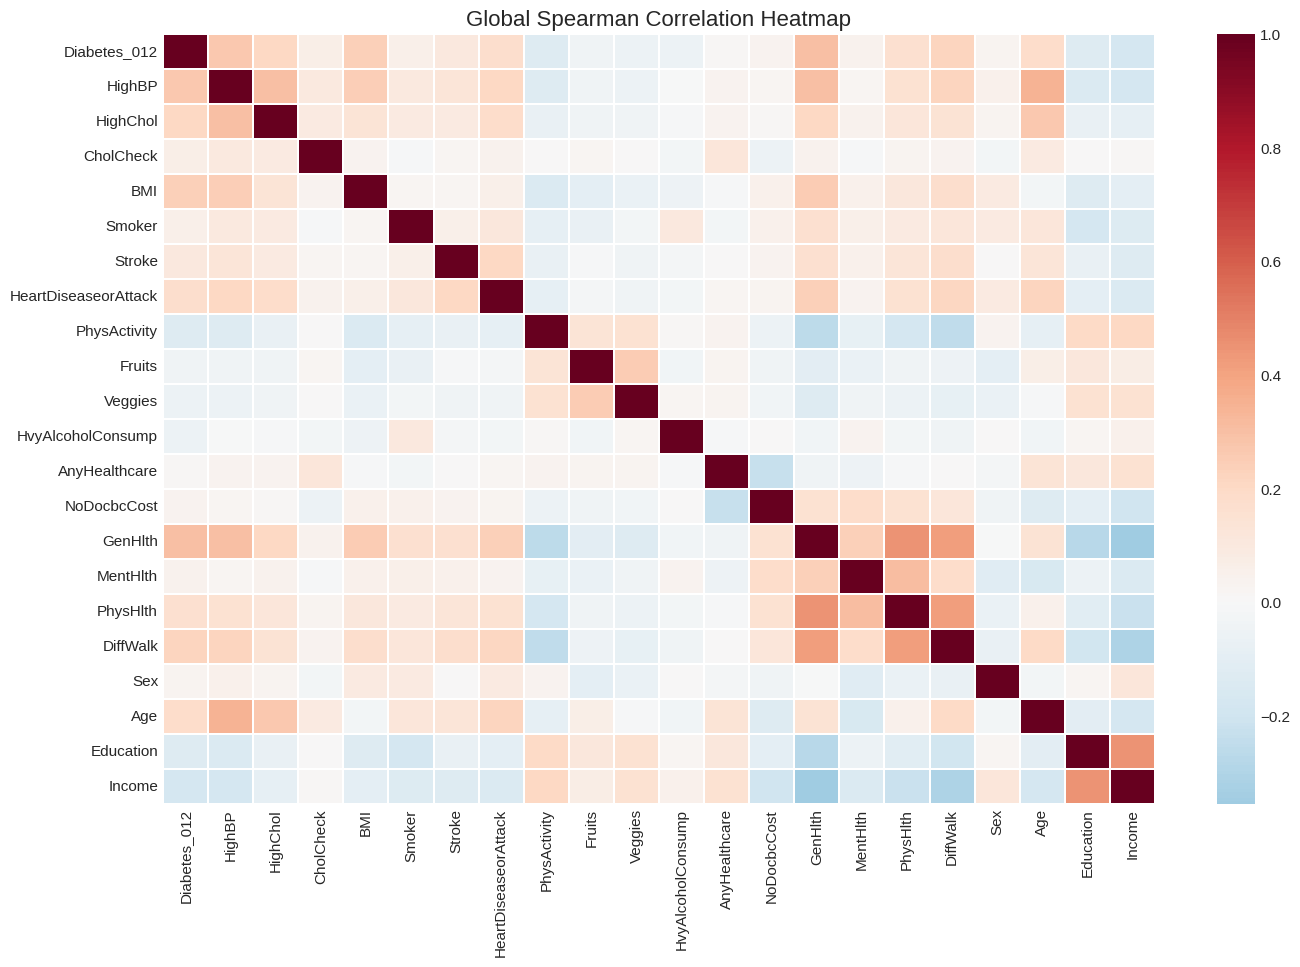

Potentially redundant pairs (High Correlation):
No pairs found with correlation > 0.7


In [ ]:
# --- Step 1: Global Multicollinearity Analysis ---
# We use Spearman because it captures monotonic relationships,
# which is ideal for the ordinal and binary variables in this dataset.

plt.figure(figsize=(16, 10))

# Calculate the correlation matrix
corr_matrix = df.corr(method='spearman')

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, linewidths=0.1)

plt.title('Global Spearman Correlation Heatmap', fontsize=16)
plt.show()

# Identifying potentially redundant variables (Correlation > 0.7 or < -0.7)
# Excluding the diagonal and the target variable
high_corr = corr_matrix[(abs(corr_matrix) > 0.7) & (abs(corr_matrix) < 1.0)]
redundant_pairs = high_corr.unstack().dropna().to_dict()

print("Potentially redundant pairs (High Correlation):")
if not redundant_pairs:
    print("No pairs found with correlation > 0.7")
else:
    for pair, value in redundant_pairs.items():
        print(f"{pair}: {value:.2f}")


<span id='WdNdhzw2o6j3'></span>
#CORRELATION WITH THE TARGET VARIABLE

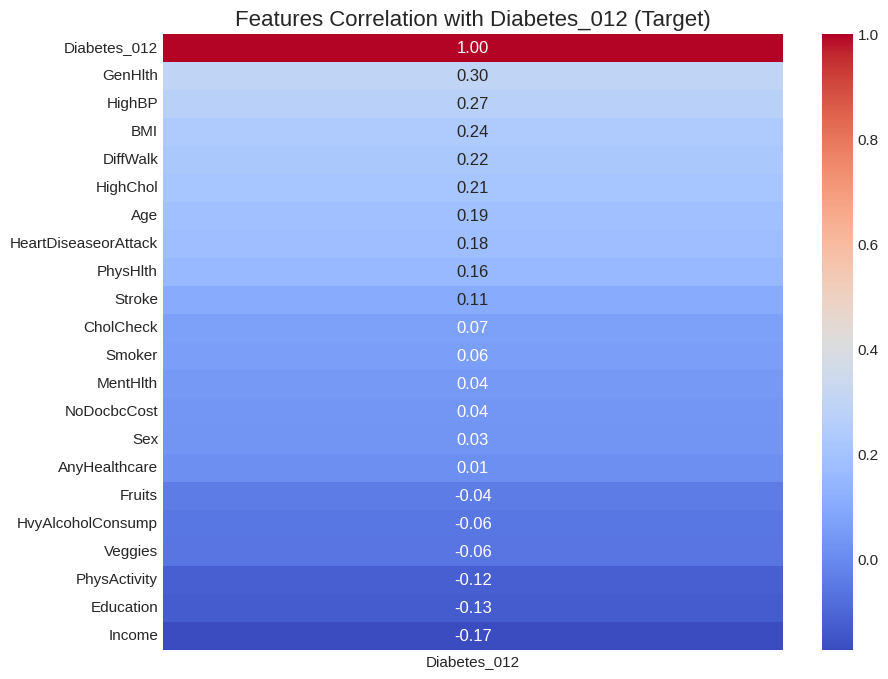

Top 5 Positive Correlates with Diabetes:
              Diabetes_012
Diabetes_012      1.000000
GenHlth           0.297138
HighBP            0.271668
BMI               0.235887
DiffWalk          0.223567
HighChol          0.210668


In [ ]:
# --- Target Correlation Analysis ---
# Visualizing how each feature correlates specifically with the Diabetes_012 status.

plt.figure(figsize=(10, 8))

# Calculating Spearman correlation with the target specifically
target_corr = df.corr(method='spearman')[['Diabetes_012']].sort_values(by='Diabetes_012', ascending=False)

# Plotting the heatmap for the target variable
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

plt.title('Features Correlation with Diabetes_012 (Target)', fontsize=16)
plt.show()

# Print the top 5 positive and negative correlates
print("Top 5 Positive Correlates with Diabetes:")
print(target_corr.head(6))


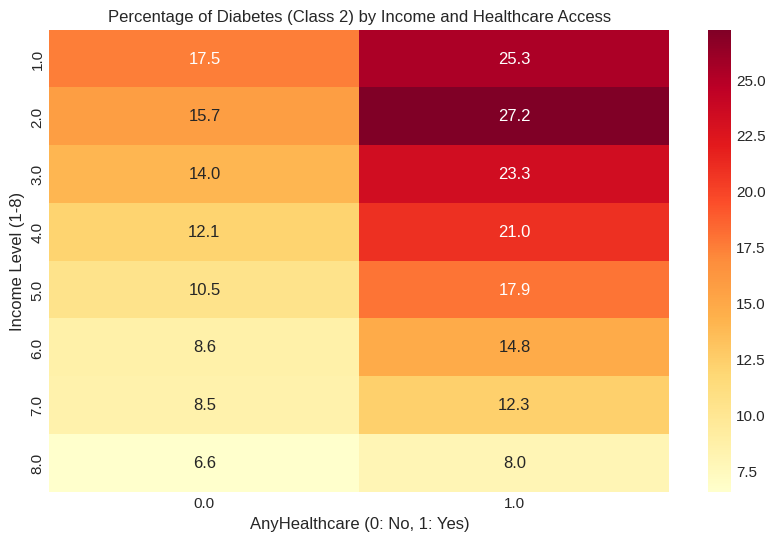

Correlation of individual features vs combined feature with Target:
Income Spearman: -0.1726
AnyHealthcare Spearman: 0.0145


In [ ]:
# --- Interaction Analysis: AnyHealthcare vs Income ---

# Create a pivot table to see the percentage of Diabetes (Class 2)
# for each combination of Income and Healthcare access.
interaction_df = df.copy()

# Focus only on Diabetic (Class 2) percentage
diabetes_rate = interaction_df.groupby(['Income', 'AnyHealthcare'])['Diabetes_012'].apply(lambda x: (x == 2).mean() * 100).unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(diabetes_rate, annot=True, fmt=".1f", cmap="YlOrRd")

plt.title('Percentage of Diabetes (Class 2) by Income and Healthcare Access')
plt.xlabel('AnyHealthcare (0: No, 1: Yes)')
plt.ylabel('Income Level (1-8)')
plt.show()

# --- Quantitative check for non-linear power ---
# We create a combined feature (Interaction Term)
interaction_df['Health_x_Income'] = interaction_df['AnyHealthcare'].astype(str) + "_" + interaction_df['Income'].astype(str)

print("Correlation of individual features vs combined feature with Target:")
print(f"Income Spearman: {df['Income'].corr(df['Diabetes_012'], method='spearman'):.4f}")
print(f"AnyHealthcare Spearman: {df['AnyHealthcare'].corr(df['Diabetes_012'], method='spearman'):.4f}")


<span id='AY4RlDgd2Mfo'></span>
#GLOBAL DATA PREPROCESSING

SECTION 1: GENERAL DUPLICATE RECORDS ANALYSIS
Total number of duplicate rows (exact matches): 23899

Sample of duplicated profiles (sorted to show identical pairs):


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0



SECTION 2: REDUNDANCY DISTRIBUTION BY CLASS
              Total Records  Duplicate Records  Percentage of Redundancy (%)
Diabetes_012                                                                
0.0                  213703              23648                     11.065825
1.0                    4631                  2                      0.043187
2.0                   35346                249                      0.704464


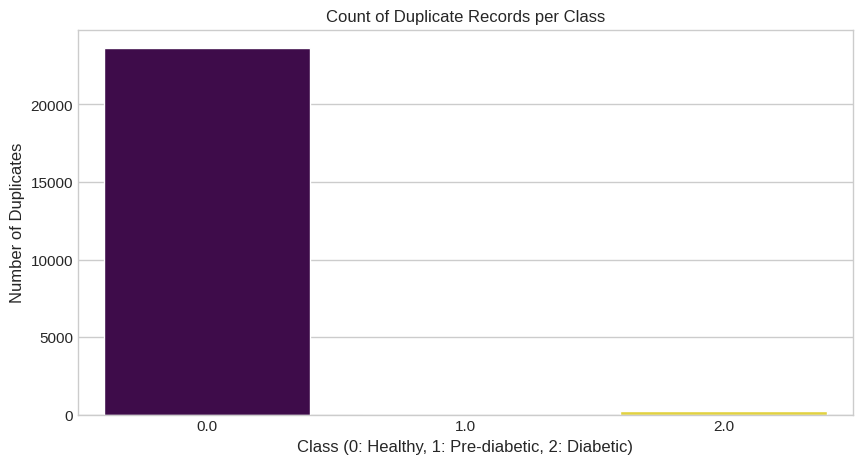


SECTION 3: AMBIGUOUS PROFILES (FEATURE OVERLAP)
Total unique ambiguous profiles found: 1834

Detailed Breakdown of Class Overlaps:
- Class 0.0 (Healthy) & Class 2.0 (Diabetic): 1497 profiles
- Class 0.0 (Healthy) & Class 1.0 (Pre-diabetic): 268 profiles
- Class 0.0 (Healthy) & Class 1.0 (Pre-diabetic) & Class 2.0 (Diabetic): 39 profiles
- Class 1.0 (Pre-diabetic) & Class 2.0 (Diabetic): 30 profiles

Total rows in dataset affected by these overlaps: 6120 (2.41%)


In [ ]:
# --- COMPREHENSIVE REDUNDANCY & AMBIGUITY ANALYSIS ---

# 1. General Duplicate Inspection
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

num_duplicates = df.duplicated().sum()
duplicate_rows = df[df.duplicated(keep=False)]

print("="*60)
print("SECTION 1: GENERAL DUPLICATE RECORDS ANALYSIS")
print("="*60)
print(f"Total number of duplicate rows (exact matches): {num_duplicates}")

if num_duplicates > 0:
    print("\nSample of duplicated profiles (sorted to show identical pairs):")
    display(duplicate_rows.sort_values(by=list(df.columns)).head(10))

# 2. Breakdown of Redundancy by Class
# 'keep=first' counts how many times a profile is "repeated" after its first appearance
duplicates_df = df[df.duplicated(keep='first')]
duplicates_per_class = duplicates_df['Diabetes_012'].value_counts().sort_index()
total_per_class = df['Diabetes_012'].value_counts().sort_index()

summary_duplicates = pd.DataFrame({
    'Total Records': total_per_class,
    'Duplicate Records': duplicates_per_class,
    'Percentage of Redundancy (%)': (duplicates_per_class / total_per_class) * 100
})

print("\n" + "="*60)
print("SECTION 2: REDUNDANCY DISTRIBUTION BY CLASS")
print("="*60)
print(summary_duplicates)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=summary_duplicates.index, y='Duplicate Records', data=summary_duplicates, palette='viridis', hue=summary_duplicates.index, legend=False)
plt.title('Count of Duplicate Records per Class')
plt.xlabel('Class (0: Healthy, 1: Pre-diabetic, 2: Diabetic)')
plt.ylabel('Number of Duplicates')
plt.show()

# 3. Ambiguous Profiles Analysis (Deterministic Noise)
# Checking for identical features that lead to different target classes
features_cols = [col for col in df.columns if col != 'Diabetes_012']
profile_targets = df.groupby(features_cols)['Diabetes_012'].unique().apply(lambda x: tuple(sorted(x)))
ambiguous_mappings = profile_targets[profile_targets.apply(len) > 1]
overlap_distribution = ambiguous_mappings.value_counts()

print("\n" + "="*60)
print("SECTION 3: AMBIGUOUS PROFILES (FEATURE OVERLAP)")
print("="*60)
print(f"Total unique ambiguous profiles found: {len(ambiguous_mappings)}")
print("\nDetailed Breakdown of Class Overlaps:")

for classes, count in overlap_distribution.items():
    class_names = {0: "Healthy", 1: "Pre-diabetic", 2: "Diabetic"}
    labels = " & ".join([f"Class {c} ({class_names[c]})" for c in classes])
    print(f"- {labels}: {count} profiles")

# Calculating the physical impact on the dataset
affected_rows = df[df.set_index(features_cols).index.isin(ambiguous_mappings.index)].shape[0]
print(f"\nTotal rows in dataset affected by these overlaps: {affected_rows} ({affected_rows/len(df)*100:.2f}%)")

<span id='lc655bTCL8nk'></span>
#TARGET ISOLATION & GROUP DEFINITION

In [ ]:
# Define the target column based on previous data exploration
target_col = 'Diabetes_012'

# 1. Isolate the features (all columns EXCEPT the target)
# We exclude the target to prevent data leakage during group identification
features_cols = [col for col in df.columns if col != target_col]

print("Generating Profile IDs...")

# 2. Create the groups array (profile_id)
# We group by all features. .ngroup() assigns a unique integer (from 0 to N)
# to each unique combination of feature values, effectively identifying identical profiles.
groups = df.groupby(features_cols, sort=False).ngroup()

# Temporarily add profile_id to the DataFrame for validation and tracking
df['profile_id'] = groups

# 3. Final separation of Features (X) and Target (y) for the ML pipeline
X = df[features_cols]
y = df[target_col]

print("Generation completed successfully!\n")

# --- SANITY CHECK ---
# Print statistics to verify the correct identification of unique vs. redundant profiles
print("="*50)
print("GROUP REPORT (PROFILE ID)")
print("="*50)
print(f"Total records in dataset:        {len(df)}")
print(f"Total unique profiles identified: {groups.nunique()}")
print(f"Redundant/Ambiguous records:     {len(df) - groups.nunique()}")
print("="*50)

# Display a sample to confirm consistent profile_id assignment
# Showing only the first 3 features, the ID, and the target for clarity
print("\nSample of profile_id assignment (first 5 rows):")
display(df[features_cols[:3] + ['profile_id', target_col]].head())

Generating Profile IDs...
Generation completed successfully!

GROUP REPORT (PROFILE ID)
Total records in dataset:        253680
Total unique profiles identified: 227908
Redundant/Ambiguous records:     25772

Sample of profile_id assignment (first 5 rows):


,HighBP,HighChol,CholCheck,profile_id,Diabetes_012
0,1.0,1.0,1.0,0,0.0
1,0.0,0.0,0.0,1,0.0
2,1.0,1.0,1.0,2,0.0
3,1.0,0.0,1.0,3,0.0
4,1.0,1.0,1.0,4,0.0


In [ ]:
#Preparation of the variables for the nested CV
SEED = 42

outer_cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

<span id='l1tqganTUGzK'></span>
#MODEL TRAINING PHASE (RANDOM FOREST)

In [ ]:
print("Configuring the validation architecture...")

# 1. MODEL AND PIPELINE DEFINITION
# class_weight='balanced' is our primary tool to handle class imbalance (focusing on class 1).
rf_classifier = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. Building the Pipeline.
pipeline_rf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', rf_classifier)
])

# 3. HYPERPARAMETER GRID DEFINITION (Tuning)
param_grid_rf = {
    'model__n_estimators': [100, 200],         # Number of trees in the forest
    'model__max_depth': [10, 20, None],        # Maximum depth (helps prevent overfitting)
    'model__min_samples_split': [2, 5, 10]     # Minimum samples required to split an internal node
}

print("Engines, Pipeline, and Parameter Grid are ready to go!")

Configuring the validation architecture...
Engines, Pipeline, and Parameter Grid are ready to go!


In [ ]:
print("Starting the Nested Stratified Group-Fold CV...\n")

# Initialize the GridSearchCV object (Inner Loop)
# The guiding metric for hyperparameter selection is F1-Macro
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=0
)

# Lists to store the results of each fold validation
cv_f1_scores_rf = []
cv_bal_acc_scores_rf = []
cv_val_scores_rf = []

# Lists to accumulate all predictions to generate the final global matrix
all_y_true_rf = []
all_y_pred_rf = []

# --- THE MANUAL OUTER LOOP ---
for i, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y, groups), total=outer_cv.get_n_splits(), desc="Outer CV Loop")):
    print(f"--- Executing Fold {i+1}/{outer_cv.get_n_splits()} ---")

    ckpt_path = CHECKPOINT_DIR / f'rf_fold_{i}.pkl'
    if ckpt_path.exists():
        data = joblib.load(ckpt_path)
        cv_f1_scores_rf.append(data['f1'])
        cv_bal_acc_scores_rf.append(data['bal_acc'])
        cv_val_scores_rf.append(data['val_score'])
        all_y_true_rf.extend(data['y_true'])
        all_y_pred_rf.extend(data['y_pred'])
        print(f"Fold {i+1} loaded from checkpoint, skipping training.\n")
        continue

    # 1. Physical splitting of data and groups
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    groups_train_fold = groups.iloc[train_idx]

    # 2. Training and Tuning (Inner Loop)
    grid_search_rf.fit(X_train_fold, y_train_fold, groups=groups_train_fold)

    # 3. Evaluation on the external Test Set (completely unseen data)
    y_pred_rf = grid_search_rf.best_estimator_.predict(X_test_fold)

    # 4. Calculation and storage of metrics
    fold_f1 = f1_score(y_test_fold, y_pred_rf, average='macro')
    fold_bal_acc = balanced_accuracy_score(y_test_fold, y_pred_rf)

    cv_f1_scores_rf.append(fold_f1)
    cv_bal_acc_scores_rf.append(fold_bal_acc)
    cv_val_scores_rf.append(grid_search_rf.best_score_)

    # Accumulate results for the final global report
    all_y_true_rf.extend(y_test_fold)
    all_y_pred_rf.extend(y_pred_rf)

    joblib.dump({
        'f1': fold_f1,
        'bal_acc': fold_bal_acc,
        'val_score': grid_search_rf.best_score_,
        'y_true': list(y_test_fold),
        'y_pred': list(y_pred_rf)
    }, ckpt_path)
    print(f"Fold {i+1} completed -> F1-Macro: {fold_f1:.4f} | Balanced Acc: {fold_bal_acc:.4f} | Checkpoint saved.\n")

# --- FINAL RESULTS ---
print("="*50)
print("FINAL RESULTS NESTED CV - RANDOM FOREST")
print("="*50)
print(f"Mean Inner Val Bal Acc:   {np.mean(cv_val_scores_rf):.4f} ± {np.std(cv_val_scores_rf):.4f}")
print(f"Mean F1-Score Macro:       {np.mean(cv_f1_scores_rf):.4f} ± {np.std(cv_f1_scores_rf):.4f}")
print(f"Mean Balanced Accuracy:    {np.mean(cv_bal_acc_scores_rf):.4f} ± {np.std(cv_bal_acc_scores_rf):.4f}")
print("="*50)

print("\nGLOBAL CLASSIFICATION REPORT:")
print(classification_report(all_y_true_rf, all_y_pred_rf, target_names=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)']))

Starting the Nested Stratified Group-Fold CV...



Outer CV Loop:   0%|          | 0/10 [00:00<?, ?it/s]

--- Executing Fold 1/10 ---
Fold 1 loaded from checkpoint, skipping training.

--- Executing Fold 2/10 ---
Fold 2 loaded from checkpoint, skipping training.

--- Executing Fold 3/10 ---
Fold 3 loaded from checkpoint, skipping training.

--- Executing Fold 4/10 ---
Fold 4 loaded from checkpoint, skipping training.

--- Executing Fold 5/10 ---
Fold 5 loaded from checkpoint, skipping training.

--- Executing Fold 6/10 ---
Fold 6 loaded from checkpoint, skipping training.

--- Executing Fold 7/10 ---
Fold 7 loaded from checkpoint, skipping training.

--- Executing Fold 8/10 ---
Fold 8 loaded from checkpoint, skipping training.

--- Executing Fold 9/10 ---
Fold 9 loaded from checkpoint, skipping training.

--- Executing Fold 10/10 ---
Fold 10 loaded from checkpoint, skipping training.

FINAL RESULTS NESTED CV - RANDOM FOREST
Mean Inner Val Bal Acc:   0.5118 ± 0.0012
Mean F1-Score Macro:       0.4316 ± 0.0028
Mean Balanced Accuracy:    0.5125 ± 0.0052

GLOBAL CLASSIFICATION REPORT:
         

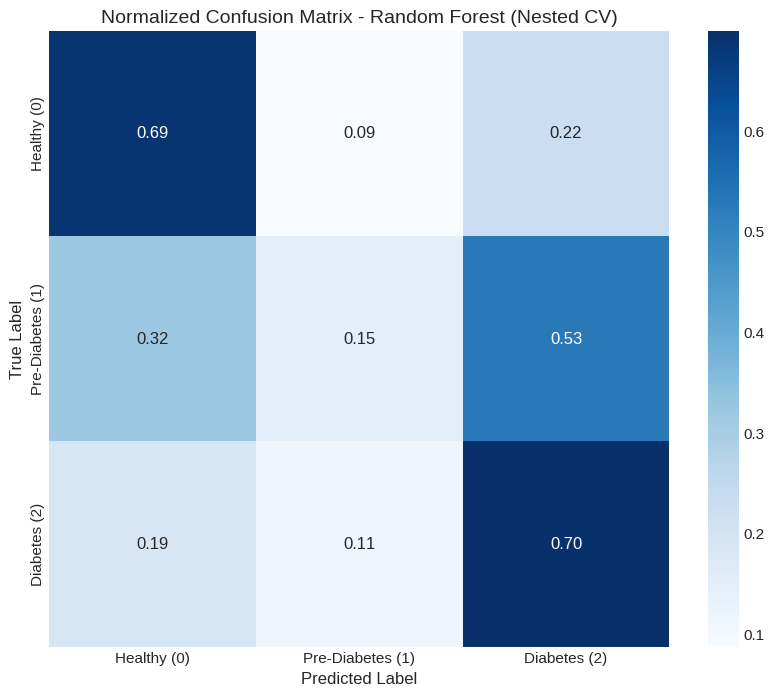

In [ ]:
# Calculate the confusion matrix for the Random Forest model
# Using the specific suffixes (_rf) to avoid overwriting variables
cm_rf = confusion_matrix(all_y_true_rf, all_y_pred_rf)

# Row-normalization to display Recall percentages for each class
cm_normalized_rf = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
# We use fmt=".2f" for floating point numbers instead of 'd' (integers)
sns.heatmap(cm_normalized_rf, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'],
            yticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'])

plt.title('Normalized Confusion Matrix - Random Forest (Nested CV)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

<span id='jt58ejQsVoho'></span>
#MODEL TRAINING PHASE (ADABOOST)

In [ ]:
print("Configuring the architecture for AdaBoost...")

# 1. DEFINITION OF THE BASE MODEL (Weak Learner)
# We use a shallow decision tree (max_depth=2).
# We insert class_weight='balanced' here to handle Class 1
base_tree = DecisionTreeClassifier(max_depth=2, class_weight='balanced', random_state=42)

# 2. ADABOOST DEFINITION
# algorithm='SAMME' is the updated standard recommended by scikit-learn
ada_classifier = AdaBoostClassifier(estimator=base_tree, algorithm='SAMME', random_state=42)

# 3. PIPELINE CREATION
pipeline_ada = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', ada_classifier)
])

# 4. HYPERPARAMETER GRID
param_grid_ada = {
    'model__n_estimators': [50, 100, 200],       # Number of iterations (sequential trees)
    'model__learning_rate': [0.05, 0.1, 0.5]     # How much "weight" we give to the corrections of each new tree
}

print("Engines, Pipeline, and Grid for AdaBoost are ready to go!")

Configuring the architecture for AdaBoost...
Engines, Pipeline, and Grid for AdaBoost are ready to go!


In [ ]:
print("Starting the Nested Stratified Group-Fold CV for AdaBoost...\n")

# Initialize the GridSearchCV object (Inner Loop) for AdaBoost
grid_search_ada = GridSearchCV(
    estimator=pipeline_ada,
    param_grid=param_grid_ada,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=0
)

# Lists to store the results of each fold validation
cv_f1_scores_ada = []
cv_bal_acc_scores_ada = []
cv_val_scores_ada = []

# Lists to accumulate all predictions to generate the final global matrix
all_y_true_ada = []
all_y_pred_ada = []

# --- THE MANUAL OUTER LOOP ---
for i, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y, groups), total=outer_cv.get_n_splits(), desc="Outer CV Loop")):
    print(f"--- Executing Fold {i+1}/{outer_cv.get_n_splits()} ---")

    ckpt_path = CHECKPOINT_DIR / f'ada_fold_{i}.pkl'
    if ckpt_path.exists():
        data = joblib.load(ckpt_path)
        cv_f1_scores_ada.append(data['f1'])
        cv_bal_acc_scores_ada.append(data['bal_acc'])
        cv_val_scores_ada.append(data['val_score'])
        all_y_true_ada.extend(data['y_true'])
        all_y_pred_ada.extend(data['y_pred'])
        print(f"Fold {i+1} loaded from checkpoint, skipping training.\n")
        continue

    # 1. Physical splitting of data and groups
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    groups_train_fold = groups.iloc[train_idx]

    # 2. Training and Tuning (Inner Loop)
    grid_search_ada.fit(X_train_fold, y_train_fold, groups=groups_train_fold)

    # 3. Evaluation on the external Test Set
    y_pred_ada = grid_search_ada.best_estimator_.predict(X_test_fold)

    # 4. Calculation and storage of metrics
    fold_f1 = f1_score(y_test_fold, y_pred_ada, average='macro')
    fold_bal_acc = balanced_accuracy_score(y_test_fold, y_pred_ada)

    cv_f1_scores_ada.append(fold_f1)
    cv_bal_acc_scores_ada.append(fold_bal_acc)
    cv_val_scores_ada.append(grid_search_ada.best_score_)

    # Accumulate results for the final global report
    all_y_true_ada.extend(y_test_fold)
    all_y_pred_ada.extend(y_pred_ada)

    joblib.dump({
        'f1': fold_f1,
        'bal_acc': fold_bal_acc,
        'val_score': grid_search_ada.best_score_,
        'y_true': list(y_test_fold),
        'y_pred': list(y_pred_ada)
    }, ckpt_path)
    print(f"Fold {i+1} completed -> F1-Macro: {fold_f1:.4f} | Balanced Acc: {fold_bal_acc:.4f} | Checkpoint saved.\n")

# --- FINAL RESULTS ---
print("="*50)
print("FINAL RESULTS NESTED CV - ADABOOST")
print("="*50)
print(f"Mean Inner Val Bal Acc:   {np.mean(cv_val_scores_ada):.4f} ± {np.std(cv_val_scores_ada):.4f}")
print(f"Mean F1-Score Macro:       {np.mean(cv_f1_scores_ada):.4f} ± {np.std(cv_f1_scores_ada):.4f}")
print(f"Mean Balanced Accuracy:    {np.mean(cv_bal_acc_scores_ada):.4f} ± {np.std(cv_bal_acc_scores_ada):.4f}")
print("="*50)

print("\nGLOBAL CLASSIFICATION REPORT:")
print(classification_report(all_y_true_ada, all_y_pred_ada, target_names=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)']))

Starting the Nested Stratified Group-Fold CV for AdaBoost...



Outer CV Loop:   0%|          | 0/10 [00:00<?, ?it/s]

--- Executing Fold 1/10 ---
Fold 1 loaded from checkpoint, skipping training.

--- Executing Fold 2/10 ---
Fold 2 loaded from checkpoint, skipping training.

--- Executing Fold 3/10 ---
Fold 3 loaded from checkpoint, skipping training.

--- Executing Fold 4/10 ---
Fold 4 loaded from checkpoint, skipping training.

--- Executing Fold 5/10 ---
Fold 5 loaded from checkpoint, skipping training.

--- Executing Fold 6/10 ---
Fold 6 loaded from checkpoint, skipping training.

--- Executing Fold 7/10 ---
Fold 7 loaded from checkpoint, skipping training.

--- Executing Fold 8/10 ---
Fold 8 loaded from checkpoint, skipping training.

--- Executing Fold 9/10 ---
Fold 9 loaded from checkpoint, skipping training.

--- Executing Fold 10/10 ---
Fold 10 loaded from checkpoint, skipping training.

FINAL RESULTS NESTED CV - ADABOOST
Mean Inner Val Bal Acc:   0.4712 ± 0.0036
Mean F1-Score Macro:       0.4066 ± 0.0266
Mean Balanced Accuracy:    0.4671 ± 0.0070

GLOBAL CLASSIFICATION REPORT:
              

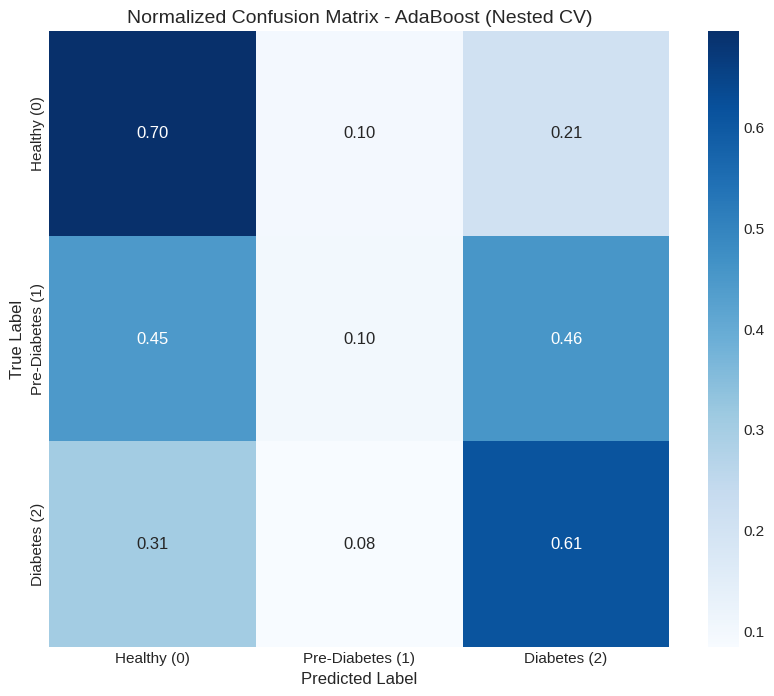

In [ ]:
# Calculate the confusion matrix for the AdaBoost model
# Ensure 'all_y_true' and 'all_y_pred' are populated during the AdaBoost CV loop
cm_ada = confusion_matrix(all_y_true_ada, all_y_pred_ada)

# Row-normalization to analyze the Recall for each class
cm_normalized_ada = cm_ada.astype('float') / cm_ada.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized_ada, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'],
            yticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'])

plt.title('Normalized Confusion Matrix - AdaBoost (Nested CV)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

#MODEL TRAINING PHASE (XGBOOST)

In [ ]:
print("Configuring the architecture for XGBoost...")

# 1. XGBOOST DEFINITION
# eval_metric='mlogloss' is set to prevent warning messages.
# We keep n_jobs=1 here because GridSearchCV will handle parallelization (n_jobs=-1).
xgb_classifier = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=1
)

# 2. PIPELINE CREATION
pipeline_xgb = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', xgb_classifier)
])

# 3. HYPERPARAMETER GRID
# XGBoost is powerful but prone to overfitting if not tuned carefully.
param_grid_xgb = {
    'model__n_estimators': [100, 200],         # Number of boosting rounds (trees)
    'model__max_depth': [3, 5, 7],             # Depth of trees (lower depth prevents overfitting)
    'model__learning_rate': [0.01, 0.1, 0.2]   # Step size shrinkage (how aggressive the learning is)
}

print("Engines, Pipeline, and Grid for XGBoost are ready to go!")

Configuring the architecture for XGBoost...
Engines, Pipeline, and Grid for XGBoost are ready to go!


In [ ]:
print("Starting the Nested Stratified Group-Fold CV for XGBoost...\n")

# Initialize the GridSearchCV object (Inner Loop) for XGBoost
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=0
)

# Lists to store the results of each fold validation
cv_f1_scores_xgb = []
cv_bal_acc_scores_xgb = []
cv_val_scores_xgb = []

# Lists to accumulate all predictions to generate the final global matrix
all_y_true_xgb = []
all_y_pred_xgb = []

# --- THE MANUAL OUTER LOOP ---
for i, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y, groups), total=outer_cv.get_n_splits(), desc="Outer CV Loop")):
    print(f"--- Executing Fold {i+1}/{outer_cv.get_n_splits()} ---")

    ckpt_path = CHECKPOINT_DIR / f'xgb_fold_{i}.pkl'
    if ckpt_path.exists():
        data = joblib.load(ckpt_path)
        cv_f1_scores_xgb.append(data['f1'])
        cv_bal_acc_scores_xgb.append(data['bal_acc'])
        cv_val_scores_xgb.append(data['val_score'])
        all_y_true_xgb.extend(data['y_true'])
        all_y_pred_xgb.extend(data['y_pred'])
        print(f"Fold {i+1} loaded from checkpoint, skipping training.\n")
        continue

    # 1. Physical splitting of data and groups
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    groups_train_fold = groups.iloc[train_idx]

    # Compute sample weights for the current training fold
    fold_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_fold)

    # 2. Training and Tuning (Inner Loop)
    grid_search_xgb.fit(
        X_train_fold,
        y_train_fold,
        groups=groups_train_fold,
        model__sample_weight=fold_sample_weights
    )

    # 3. Evaluation on the external Test Set
    y_pred_xgb = grid_search_xgb.best_estimator_.predict(X_test_fold)

    # 4. Calculation and storage of metrics
    fold_f1 = f1_score(y_test_fold, y_pred_xgb, average='macro')
    fold_bal_acc = balanced_accuracy_score(y_test_fold, y_pred_xgb)

    cv_f1_scores_xgb.append(fold_f1)
    cv_bal_acc_scores_xgb.append(fold_bal_acc)
    cv_val_scores_xgb.append(grid_search_xgb.best_score_)

    # Accumulate results for the final global report
    all_y_true_xgb.extend(y_test_fold)
    all_y_pred_xgb.extend(y_pred_xgb)

    joblib.dump({
        'f1': fold_f1,
        'bal_acc': fold_bal_acc,
        'val_score': grid_search_xgb.best_score_,
        'y_true': list(y_test_fold),
        'y_pred': list(y_pred_xgb)
    }, ckpt_path)
    print(f"Fold {i+1} completed -> F1-Macro: {fold_f1:.4f} | Balanced Acc: {fold_bal_acc:.4f} | Checkpoint saved.\n")

# --- FINAL RESULTS ---
print("="*50)
print("FINAL RESULTS NESTED CV - XGBOOST")
print("="*50)
print(f"Mean Inner Val Bal Acc:   {np.mean(cv_val_scores_xgb):.4f} ± {np.std(cv_val_scores_xgb):.4f}")
print(f"Mean F1-Score Macro:       {np.mean(cv_f1_scores_xgb):.4f} ± {np.std(cv_f1_scores_xgb):.4f}")
print(f"Mean Balanced Accuracy:    {np.mean(cv_bal_acc_scores_xgb):.4f} ± {np.std(cv_bal_acc_scores_xgb):.4f}")
print("="*50)

print("\nGLOBAL CLASSIFICATION REPORT:")
print(classification_report(all_y_true_xgb, all_y_pred_xgb, target_names=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)']))

Starting the Nested Stratified Group-Fold CV for XGBoost...



Outer CV Loop:   0%|          | 0/10 [00:00<?, ?it/s]

--- Executing Fold 1/10 ---
Fold 1 loaded from checkpoint, skipping training.

--- Executing Fold 2/10 ---
Fold 2 loaded from checkpoint, skipping training.

--- Executing Fold 3/10 ---
Fold 3 loaded from checkpoint, skipping training.

--- Executing Fold 4/10 ---
Fold 4 loaded from checkpoint, skipping training.

--- Executing Fold 5/10 ---
Fold 5 loaded from checkpoint, skipping training.

--- Executing Fold 6/10 ---
Fold 6 loaded from checkpoint, skipping training.

--- Executing Fold 7/10 ---
Fold 7 loaded from checkpoint, skipping training.

--- Executing Fold 8/10 ---
Fold 8 loaded from checkpoint, skipping training.

--- Executing Fold 9/10 ---
Fold 9 loaded from checkpoint, skipping training.

--- Executing Fold 10/10 ---
Fold 10 loaded from checkpoint, skipping training.

FINAL RESULTS NESTED CV - XGBOOST
Mean Inner Val Bal Acc:   0.5240 ± 0.0017
Mean F1-Score Macro:       0.4211 ± 0.0035
Mean Balanced Accuracy:    0.5259 ± 0.0075

GLOBAL CLASSIFICATION REPORT:
               

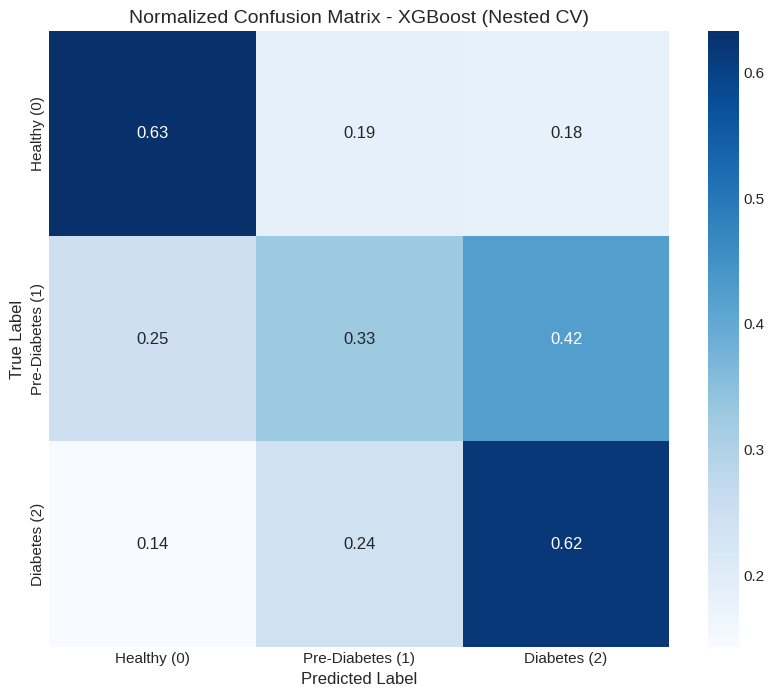

In [ ]:
# Calculate the confusion matrix using the lists accumulated during the Nested CV loops
# 'all_y_true' contains the ground truth, 'all_y_pred' contains XGBoost's predictions
cm = confusion_matrix(all_y_true_xgb, all_y_pred_xgb)

# Row-normalization to display Recall percentages for each class
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'],
            yticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'])

plt.title('Normalized Confusion Matrix - XGBoost (Nested CV)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

#MODEL TRAINING PHASE (NAIVE BAYES)


In [ ]:
# --- BALANCED NAIVE BAYES CONFIGURATION ---
nb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # Force the model to treat all classes as equally likely (1/3 each)
    ('nb', GaussianNB(priors=[1/3, 1/3, 1/3]))
])

nb_param_grid = {'nb__var_smoothing': np.logspace(0, -9, num=20)}


In [ ]:
# --- NESTED CV TRAINING LOOP ---
print("Starting the Nested Stratified Group-Fold CV (Naive Bayes)...\n")

nb_grid_search = GridSearchCV(
    estimator=nb_pipeline,
    param_grid=nb_param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1
)

nb_nested_f1_scores = []
nb_nested_ba_scores = []
nb_val_scores = []
nb_all_preds = []
nb_all_true = []

for i, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y, groups), total=outer_cv.get_n_splits(), desc="Outer CV Loop")):
    print(f"--- Executing Fold {i+1}/{outer_cv.get_n_splits()} ---")

    ckpt_path = CHECKPOINT_DIR / f'nb_fold_{i}.pkl'
    if ckpt_path.exists():
        data = joblib.load(ckpt_path)
        nb_nested_f1_scores.append(data['f1'])
        nb_nested_ba_scores.append(data['ba'])
        nb_val_scores.append(data['val_score'])
        nb_all_true.extend(data['y_true'])
        nb_all_preds.extend(data['y_pred'])
        print(f"Fold {i+1} loaded from checkpoint, skipping training.\n")
        continue

    # Split data into training and test sets for this fold
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    groups_train_fold = groups.iloc[train_idx]

    # Execute Hyperparameter search (Inner Loop)
    nb_grid_search.fit(X_train_fold, y_train_fold, groups=groups_train_fold)

    # Make predictions on the unseen outer fold
    y_pred_nb = nb_grid_search.best_estimator_.predict(X_test_fold)

    # Calculate fold metrics
    f1_fold = f1_score(y_test_fold, y_pred_nb, average='macro')
    ba_fold = balanced_accuracy_score(y_test_fold, y_pred_nb)

    # Store results
    nb_nested_f1_scores.append(f1_fold)
    nb_nested_ba_scores.append(ba_fold)
    nb_val_scores.append(nb_grid_search.best_score_)

    nb_all_preds.extend(y_pred_nb)
    nb_all_true.extend(y_test_fold)

    joblib.dump({
        'f1': f1_fold,
        'ba': ba_fold,
        'val_score': nb_grid_search.best_score_,
        'y_true': list(y_test_fold),
        'y_pred': list(y_pred_nb)
    }, ckpt_path)
    print(f"Fold {i+1} completed -> F1-Macro: {f1_fold:.4f} | Balanced Acc: {ba_fold:.4f} | Checkpoint saved.\n")

# --- FINAL SUMMARY REPORT ---
print("="*50)
print("FINAL RESULTS NESTED CV - NAIVE BAYES")
print("="*50)
print(f"Mean Inner Val Bal Acc:   {np.mean(nb_val_scores):.4f} ± {np.std(nb_val_scores):.4f}")
print(f"Mean F1-Score Macro:       {np.mean(nb_nested_f1_scores):.4f} ± {np.std(nb_nested_f1_scores):.4f}")
print(f"Mean Balanced Accuracy:    {np.mean(nb_nested_ba_scores):.4f} ± {np.std(nb_nested_ba_scores):.4f}")
print("="*50)

print("\nGLOBAL CLASSIFICATION REPORT:")
target_names = ['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)']
print(classification_report(nb_all_true, nb_all_preds, target_names=target_names))

Starting the Nested Stratified Group-Fold CV (Naive Bayes)...



Outer CV Loop:   0%|          | 0/10 [00:00<?, ?it/s]

--- Executing Fold 1/10 ---
Fold 1 loaded from checkpoint, skipping training.

--- Executing Fold 2/10 ---
Fold 2 loaded from checkpoint, skipping training.

--- Executing Fold 3/10 ---
Fold 3 loaded from checkpoint, skipping training.

--- Executing Fold 4/10 ---
Fold 4 loaded from checkpoint, skipping training.

--- Executing Fold 5/10 ---
Fold 5 loaded from checkpoint, skipping training.

--- Executing Fold 6/10 ---
Fold 6 loaded from checkpoint, skipping training.

--- Executing Fold 7/10 ---
Fold 7 loaded from checkpoint, skipping training.

--- Executing Fold 8/10 ---
Fold 8 loaded from checkpoint, skipping training.

--- Executing Fold 9/10 ---
Fold 9 loaded from checkpoint, skipping training.

--- Executing Fold 10/10 ---
Fold 10 loaded from checkpoint, skipping training.

FINAL RESULTS NESTED CV - NAIVE BAYES
Mean Inner Val Bal Acc:   0.4889 ± 0.0007
Mean F1-Score Macro:       0.4220 ± 0.0030
Mean Balanced Accuracy:    0.4889 ± 0.0057

GLOBAL CLASSIFICATION REPORT:
           

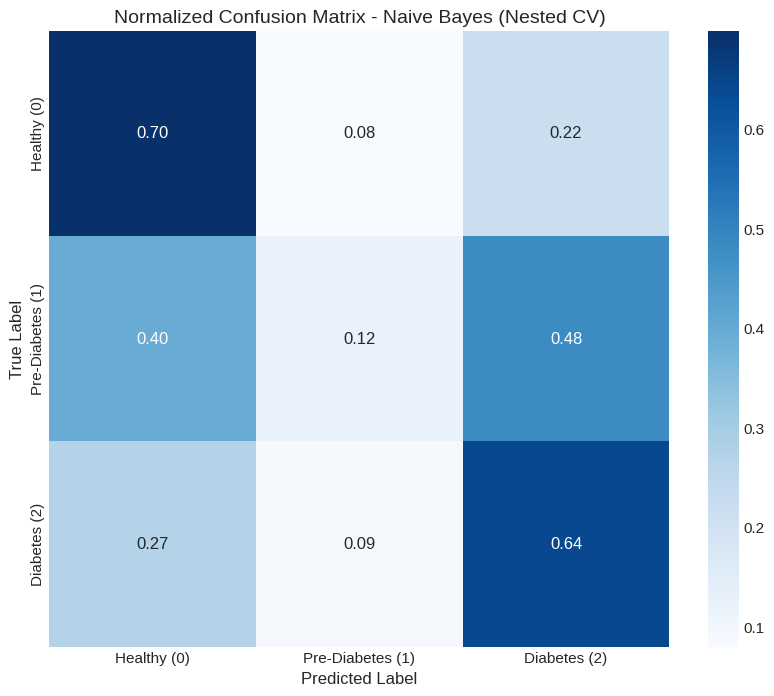

In [ ]:
# Calculate the confusion matrix using the lists accumulated during the Nested CV loops
# 'nb_all_true' contains the ground truth, 'nb_all_preds' contains Naive Bayes's predictions
cm = confusion_matrix(nb_all_true, nb_all_preds)

# Row-normalization to display Recall percentages for each class
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'],
            yticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'])

plt.title('Normalized Confusion Matrix - Naive Bayes (Nested CV)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

#MODEL TRAINING PHASE (LOGISTIC REGRESSION)

In [ ]:
# 1. PIPELINE DEFINITION
# We use 'multinomial' for 3-class support and 'balanced' to handle class imbalance
lr_model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

lr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', lr_model)
])

# 2. HYPERPARAMETER GRID
# 'C' is the inverse of regularization strength (smaller values = stronger regularization)
lr_param_grid = {
    'model__C': [0.1, 1.0, 10.0]
}

print("Logistic Regression Pipeline and Grid Search ready!")

Logistic Regression Pipeline and Grid Search ready!


In [ ]:
# --- NESTED CV TRAINING LOOP (Logistic Regression) ---
print("Starting the Nested Stratified Group-Fold CV (Logistic Regression)...\n")

lr_grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=inner_cv,
    scoring='balanced_accuracy',
    n_jobs=-1
)

# Initialize containers for results
lr_nested_f1_scores = []
lr_nested_ba_scores = []
lr_val_scores = []
lr_all_preds = []
lr_all_true = []

for i, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y, groups), total=outer_cv.get_n_splits(), desc="Outer CV Loop")):
    print(f"--- Executing Fold {i+1}/{outer_cv.get_n_splits()} ---")

    ckpt_path = CHECKPOINT_DIR / f'lr_fold_{i}.pkl'
    if ckpt_path.exists():
        data = joblib.load(ckpt_path)
        lr_nested_f1_scores.append(data['f1'])
        lr_nested_ba_scores.append(data['ba'])
        lr_val_scores.append(data['val_score'])
        lr_all_true.extend(data['y_true'])
        lr_all_preds.extend(data['y_pred'])
        print(f"Fold {i+1} loaded from checkpoint, skipping training.\n")
        continue

    # Split data ensuring patients (groups) are kept together
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
    groups_train_fold = groups.iloc[train_idx]

    # Execute Inner Loop for hyperparameter tuning
    lr_grid_search.fit(X_train_fold, y_train_fold, groups=groups_train_fold)

    # Predict on the unseen outer fold
    y_pred_lr = lr_grid_search.best_estimator_.predict(X_test_fold)

    # Metrics calculation
    f1_fold = f1_score(y_test_fold, y_pred_lr, average='macro')
    ba_fold = balanced_accuracy_score(y_test_fold, y_pred_lr)

    # Store results for global analysis
    lr_nested_f1_scores.append(f1_fold)
    lr_nested_ba_scores.append(ba_fold)
    lr_val_scores.append(lr_grid_search.best_score_)

    lr_all_preds.extend(y_pred_lr)
    lr_all_true.extend(y_test_fold)

    joblib.dump({
        'f1': f1_fold,
        'ba': ba_fold,
        'val_score': lr_grid_search.best_score_,
        'y_true': list(y_test_fold),
        'y_pred': list(y_pred_lr)
    }, ckpt_path)
    print(f"Fold {i+1} completed -> F1-Macro: {f1_fold:.4f} | Balanced Acc: {ba_fold:.4f} | Checkpoint saved.\n")

# --- FINAL SUMMARY REPORT ---
print("="*50)
print("FINAL RESULTS NESTED CV - LOGISTIC REGRESSION")
print("="*50)
print(f"Mean Inner Val Bal Acc:   {np.mean(lr_val_scores):.4f} ± {np.std(lr_val_scores):.4f}")
print(f"Mean F1-Score Macro:       {np.mean(lr_nested_f1_scores):.4f} ± {np.std(lr_nested_f1_scores):.4f}")
print(f"Mean Balanced Accuracy:    {np.mean(lr_nested_ba_scores):.4f} ± {np.std(lr_nested_ba_scores):.4f}")
print("="*50)

print("\nGLOBAL CLASSIFICATION REPORT:")
target_names = ['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)']
print(classification_report(lr_all_true, lr_all_preds, target_names=target_names))

Starting the Nested Stratified Group-Fold CV (Logistic Regression)...



Outer CV Loop:   0%|          | 0/10 [00:00<?, ?it/s]

--- Executing Fold 1/10 ---
Fold 1 loaded from checkpoint, skipping training.

--- Executing Fold 2/10 ---
Fold 2 loaded from checkpoint, skipping training.

--- Executing Fold 3/10 ---
Fold 3 loaded from checkpoint, skipping training.

--- Executing Fold 4/10 ---
Fold 4 loaded from checkpoint, skipping training.

--- Executing Fold 5/10 ---
Fold 5 loaded from checkpoint, skipping training.

--- Executing Fold 6/10 ---
Fold 6 loaded from checkpoint, skipping training.

--- Executing Fold 7/10 ---
Fold 7 loaded from checkpoint, skipping training.

--- Executing Fold 8/10 ---
Fold 8 loaded from checkpoint, skipping training.

--- Executing Fold 9/10 ---
Fold 9 loaded from checkpoint, skipping training.

--- Executing Fold 10/10 ---
Fold 10 loaded from checkpoint, skipping training.

FINAL RESULTS NESTED CV - LOGISTIC REGRESSION
Mean Inner Val Bal Acc:   0.5194 ± 0.0011
Mean F1-Score Macro:       0.4269 ± 0.0027
Mean Balanced Accuracy:    0.5200 ± 0.0054

GLOBAL CLASSIFICATION REPORT:
   

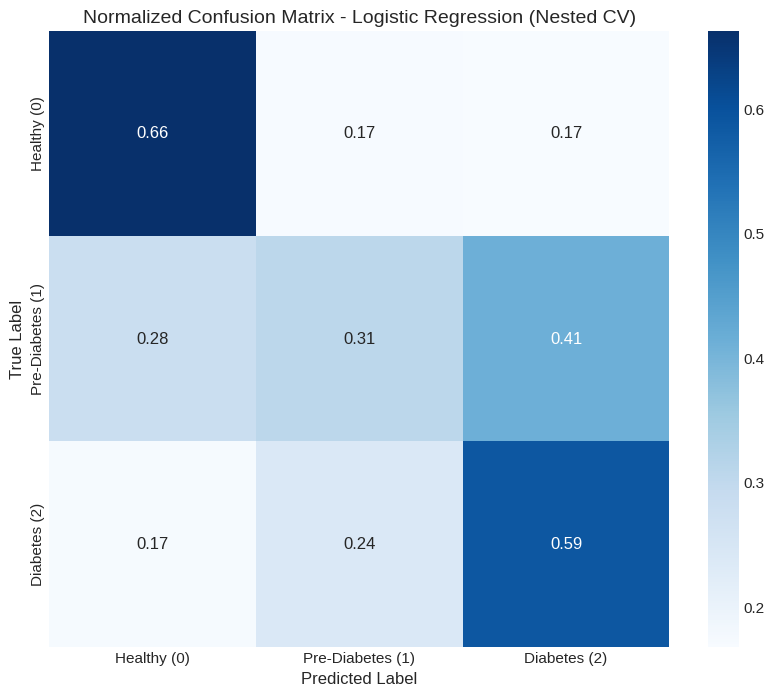

In [ ]:
# Calculate the confusion matrix using the lists accumulated during the Nested CV loops
# 'lr_all_true' contains the ground truth, 'lr_all_preds' contains Logistic Regression's predictions
cm = confusion_matrix(lr_all_true, lr_all_preds)

# Row-normalization to display Recall percentages for each class
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap='Blues',
            xticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'],
            yticklabels=['Healthy (0)', 'Pre-Diabetes (1)', 'Diabetes (2)'])

plt.title('Normalized Confusion Matrix - Logistic Regression (Nested CV)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

#**MODELS' COMPARISON**

In [ ]:
# 1. Collect scores in dictionaries for easier processing
f1_scores_dict = {
    'Random Forest': cv_f1_scores_rf,
    'AdaBoost': cv_f1_scores_ada,
    'XGBoost': cv_f1_scores_xgb,
    'Naive Bayes': nb_nested_f1_scores,
    'Logistic Regression': lr_nested_f1_scores
}

ba_scores_dict = {
    'Random Forest': cv_bal_acc_scores_rf,
    'AdaBoost': cv_bal_acc_scores_ada,
    'XGBoost': cv_bal_acc_scores_xgb,
    'Naive Bayes': nb_nested_ba_scores,
    'Logistic Regression': lr_nested_ba_scores
}

# 2. Initialize a list to hold the rows of our table
results_list = []

# 3. Calculate Mean and Standard Deviation for each model
for model_name in f1_scores_dict.keys():
    # F1 Score
    f1_mean = np.mean(f1_scores_dict[model_name])
    f1_std = np.std(f1_scores_dict[model_name])

    # Balanced Accuracy
    ba_mean = np.mean(ba_scores_dict[model_name])
    ba_std = np.std(ba_scores_dict[model_name])

    # Format strings to display as "Mean ± Std"
    results_list.append({
        'Model': model_name,
        'F1-Score Macro (Mean ± Std)': f"{f1_mean:.4f} ± {f1_std:.4f}",
        'Balanced Acc (Mean ± Std)': f"{ba_mean:.4f} ± {ba_std:.4f}",
        # Keep the raw numeric value for sorting purposes
        'F1_Mean_Numeric': f1_mean
    })

# 4. Create the DataFrame and sort it from best to worst based on F1-Score
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='F1_Mean_Numeric', ascending=False).drop(columns=['F1_Mean_Numeric'])

# Reset the index for a cleaner look
results_df = results_df.reset_index(drop=True)

# 5. Display the table
print("--- Model Performance Comparison (Nested CV) ---")
display(results_df)

--- Model Performance Comparison (Nested CV) ---


,Model,F1-Score Macro (Mean ± Std),Balanced Acc (Mean ± Std)
0,Random Forest,0.4316 ± 0.0028,0.5125 ± 0.0052
1,Logistic Regression,0.4269 ± 0.0027,0.5200 ± 0.0054
2,Naive Bayes,0.4220 ± 0.0030,0.4889 ± 0.0057
3,XGBoost,0.4211 ± 0.0035,0.5259 ± 0.0075
4,AdaBoost,0.4066 ± 0.0266,0.4671 ± 0.0070


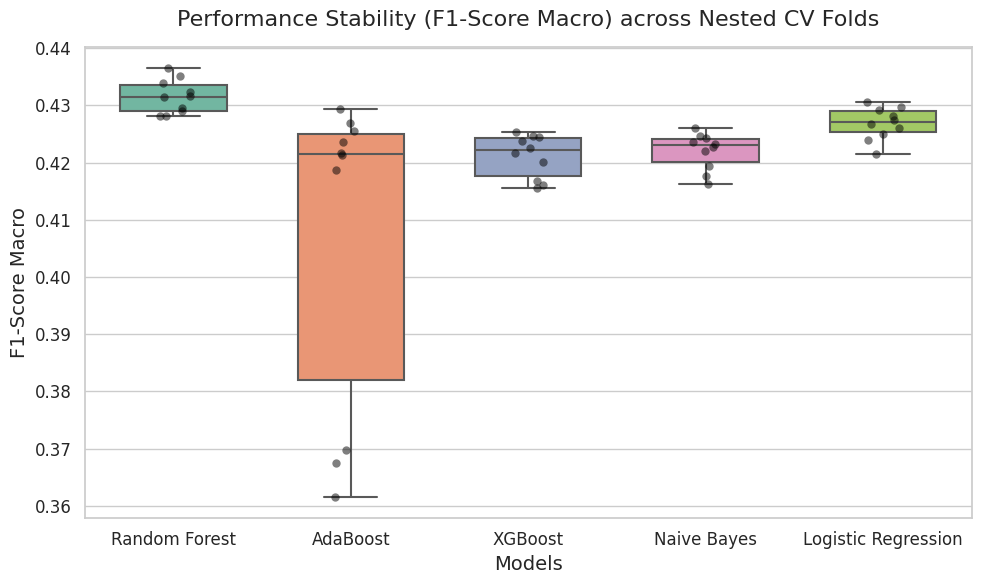

In [ ]:
# 1. Create a structured DataFrame for Seaborn using the previous dictionary
# Each column represents a model, and the rows are the cross-validation folds
f1_df = pd.DataFrame(f1_scores_dict)

# 2. Set the plot style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid") # Adds a clean, elegant grid

# 3. Draw the Boxplot
# Use a harmonious color palette
ax = sns.boxplot(data=f1_df, palette="Set2", width=0.6, linewidth=1.5)

# Add individual data points on top (stripplot) to show the exact results of the 5 folds
sns.stripplot(data=f1_df, color='black', alpha=0.5, jitter=True, size=6)

# 4. Customize Titles and Axes
plt.title('Performance Stability (F1-Score Macro) across Nested CV Folds', fontsize=16, pad=15)
plt.ylabel('F1-Score Macro', fontsize=14)
plt.xlabel('Models', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

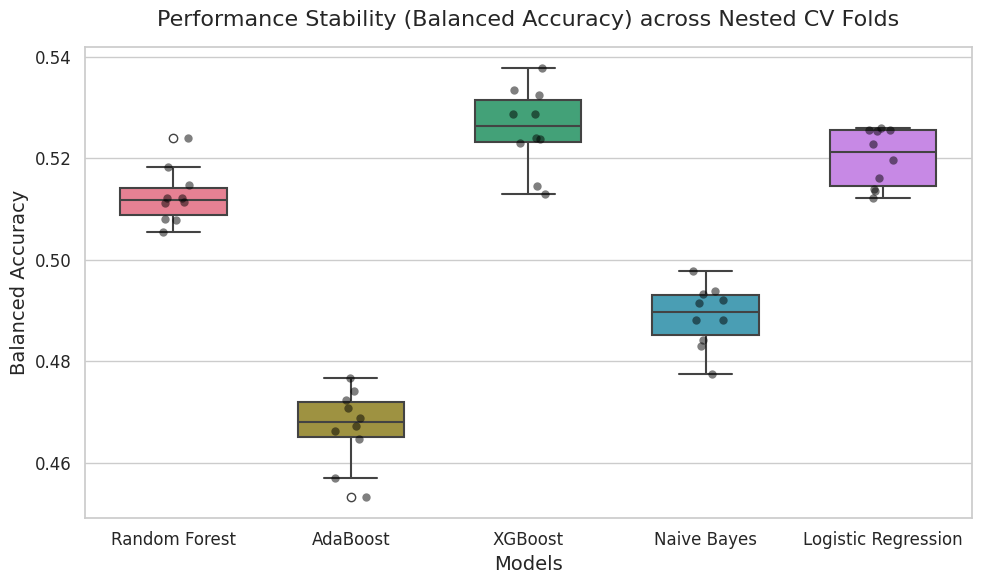

In [ ]:
# 1. Convert the Balanced Accuracy dictionary into a "Long-Form" DataFrame
# This method safely handles plotting multiple groups
ba_data_long = []
for model_name, scores in ba_scores_dict.items():
    for score in scores:
        ba_data_long.append({'Model': model_name, 'Balanced Accuracy': score})

ba_df_long = pd.DataFrame(ba_data_long)

# 2. Set the plot style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Draw the Boxplot
# Using the "husl" palette to visually distinguish it from the F1-Score plot
ax = sns.boxplot(x='Model', y='Balanced Accuracy', data=ba_df_long, palette="husl", width=0.6, linewidth=1.5)

# Add the individual fold data points on top
sns.stripplot(x='Model', y='Balanced Accuracy', data=ba_df_long, color='black', alpha=0.5, jitter=True, size=6)

# 4. Customize Titles and Axes
plt.title('Performance Stability (Balanced Accuracy) across Nested CV Folds', fontsize=16, pad=15)
plt.ylabel('Balanced Accuracy', fontsize=14)
plt.xlabel('Models', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

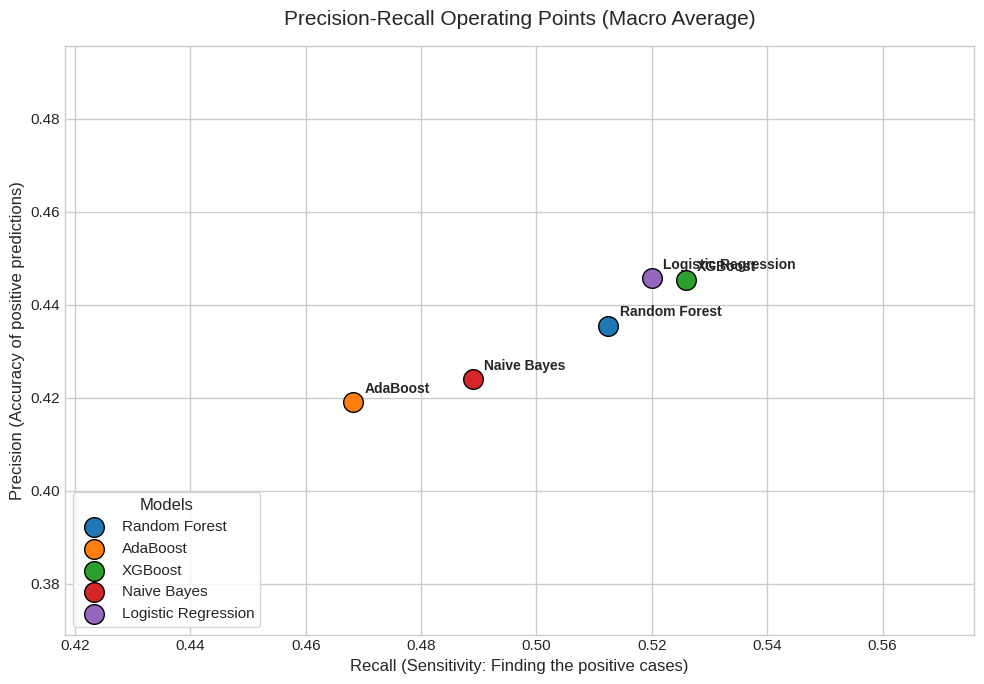

--- Precision & Recall Numerical Values ---


,Model,Precision,Recall
0,XGBoost,0.445295,0.525841
1,Logistic Regression,0.445684,0.519953
2,Random Forest,0.435524,0.512413
3,Naive Bayes,0.424040,0.488943
4,AdaBoost,0.419058,0.468282


In [ ]:
# 1. Retrieve the True labels and Predicted labels for each model from the dictionary
models_data = {
    'Random Forest': (all_y_true_rf, all_y_pred_rf),
    'AdaBoost': (all_y_true_ada, all_y_pred_ada),
    'XGBoost': (all_y_true_xgb, all_y_pred_xgb),
    'Naive Bayes': (nb_all_true, nb_all_preds),
    'Logistic Regression': (lr_all_true, lr_all_preds)
}

# 2. Calculate Macro Precision and Macro Recall
pr_results = []
for model_name, (y_true, y_pred) in models_data.items():
    # We use 'macro' to treat all 3 classes equally, regardless of imbalance
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

    pr_results.append({
        'Model': model_name,
        'Precision': precision,
        'Recall': recall
    })

pr_df = pd.DataFrame(pr_results)

# 3. Create the Precision-Recall Scatter Plot
plt.figure(figsize=(10, 7))
plt.style.use('seaborn-v0_8-whitegrid') # Clean academic style

# Define a distinct color for each model
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Plot each model as a dot
for idx, row in pr_df.iterrows():
    plt.scatter(row['Recall'], row['Precision'], label=row['Model'],
                color=colors[idx], s=200, edgecolor='black', zorder=5)

    # Add a small text label near the dot for readability
    plt.text(row['Recall'] + 0.002, row['Precision'] + 0.002, row['Model'],
             fontsize=10, fontweight='semibold')

# 4. Customize the plot
plt.title('Precision-Recall Operating Points (Macro Average)', fontsize=15, pad=15)
plt.xlabel('Recall (Sensitivity: Finding the positive cases)', fontsize=12)
plt.ylabel('Precision (Accuracy of positive predictions)', fontsize=12)

plt.plot([0, 1], [1, 1], linestyle='--', color='gray', alpha=0.5)
plt.plot([1, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)

# Set axes limits slightly wider than the data points for better visibility
plt.xlim(pr_df['Recall'].min() - 0.05, pr_df['Recall'].max() + 0.05)
plt.ylim(pr_df['Precision'].min() - 0.05, pr_df['Precision'].max() + 0.05)

plt.legend(title="Models", loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

# Print the numerical values
print("--- Precision & Recall Numerical Values ---")
display(pr_df.sort_values(by='Recall', ascending=False).reset_index(drop=True))

In [ ]:
# 1. Select the Balanced Accuracy scores for the two main contenders
# We compare our chosen model (LR) against the best performer in F1 (RF)
model_a_scores = ba_scores_dict['Logistic Regression']
model_b_scores = ba_scores_dict['Random Forest']

# 2. Execute the Wilcoxon Signed-Rank Test
# This test checks if the median of the differences between the two groups is zero
stat, p_value = wilcoxon(model_a_scores, model_b_scores)

print("=== WILCOXON SIGNED-RANK TEST (Balanced Accuracy) ===")
print(f"Comparison: Logistic Regression vs Random Forest")
print(f"Test Statistic: {stat:.3f}")
print(f"P-value: {p_value:.4f}")

=== WILCOXON SIGNED-RANK TEST (Balanced Accuracy) ===
Comparison: Logistic Regression vs Random Forest
Test Statistic: 0.000
P-value: 0.0020


In [ ]:
# 1. Select the Balanced Accuracy scores for the top two performers on this metric
# XGBoost (1st) vs Logistic Regression (2nd)
lr_ba_scores = ba_scores_dict['Logistic Regression']
xgb_ba_scores = ba_scores_dict['XGBoost']

# 2. Execute the Wilcoxon Signed-Rank Test
# This is a non-parametric test for paired samples (the same 10 CV folds)
stat_lr_xgb, p_value_lr_xgb = wilcoxon(lr_ba_scores, xgb_ba_scores)

print("=== WILCOXON SIGNED-RANK TEST (Balanced Accuracy) ===")
print(f"Comparison: Logistic Regression vs XGBoost")
print(f"Test Statistic: {stat_lr_xgb:.3f}")
print(f"P-value: {p_value_lr_xgb:.4f}")

=== WILCOXON SIGNED-RANK TEST (Balanced Accuracy) ===
Comparison: Logistic Regression vs XGBoost
Test Statistic: 9.000
P-value: 0.0645


#**FINAL MODEL TUNING AND TRAINING**

In [ ]:
final_ckpt_path = CHECKPOINT_DIR / 'final_model.pkl'

if final_ckpt_path.exists():
    saved = joblib.load(final_ckpt_path)
    best_model = saved['best_model']
    best_hparams = saved['best_hparams']
    cv_results = saved['cv_results']
    best_score = saved['best_score']
    print(f"Final model loaded from checkpoint.")
    print(f"Best Hyperparameters: {best_hparams}")
else:
    # 1. Define the machine learning pipeline
    final_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            multi_class='multinomial',
            solver='lbfgs',
            class_weight='balanced',
            random_state=42,
            max_iter=2000
        ))
    ])

    # 2. Define the hyperparameter grid for tuning
    param_grid = {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100]
    }

    # 3. Setup the cross-validation strategy
    final_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

    # 4. Initialize GridSearchCV
    grid_search = GridSearchCV(
        estimator=final_pipeline,
        param_grid=param_grid,
        cv=final_cv,
        scoring='balanced_accuracy',
        verbose=1,
        n_jobs=-1
    )

    # 5. Run the grid search
    grid_search.fit(X, y, groups=groups)

    # 6. Extract the Best Results
    best_hparams = grid_search.best_params_
    best_model = grid_search.best_estimator_
    cv_results = grid_search.cv_results_
    best_score = grid_search.best_score_

    joblib.dump({
        'best_model': best_model,
        'best_hparams': best_hparams,
        'cv_results': cv_results,
        'best_score': best_score
    }, final_ckpt_path)
    print(f"Final model trained and saved to checkpoint.")
    print(f"Best Hyperparameters: {best_hparams}")
    print(f"Best Balanced Accuracy Score: {best_score:.4f}")

# 7. Final Parameters (Coefficients)
feature_names = X.columns
logistic_regression_step = best_model.named_steps['model']

coef_df = pd.DataFrame(
    logistic_regression_step.coef_,
    columns=feature_names,
    index=['Healthy (Class 0)', 'Pre-Diabetes (Class 1)', 'Diabetes (Class 2)']
)

print("\n--- Final Model Parameters (Coefficients) ---")
display(coef_df.T)

print("\n--- Final Model Intercepts ---")
intercept_df = pd.DataFrame(
    logistic_regression_step.intercept_,
    index=['Healthy (Class 0)', 'Pre-Diabetes (Class 1)', 'Diabetes (Class 2)'],
    columns=['Intercept']
)
display(intercept_df)

Final model loaded from checkpoint.
Best Hyperparameters: {'model__C': 0.1}

--- Final Model Parameters (Coefficients) ---


,Healthy (Class 0),Pre-Diabetes (Class 1),Diabetes (Class 2)
HighBP,-0.182477,-0.002031,0.184508
HighChol,-0.197959,0.088206,0.109754
CholCheck,-0.137264,0.026756,0.110508
BMI,-0.317272,0.103389,0.213884
Smoker,0.006547,-0.005250,-0.001296
Stroke,-0.005040,-0.021201,0.026241
HeartDiseaseorAttack,-0.022624,-0.025977,0.048602
PhysActivity,0.014452,0.002194,-0.016646
Fruits,0.011749,0.001030,-0.012779
Veggies,0.011296,-0.008620,-0.002676



--- Final Model Intercepts ---


,Intercept
Healthy (Class 0),0.325321
Pre-Diabetes (Class 1),0.029230
Diabetes (Class 2),-0.354552


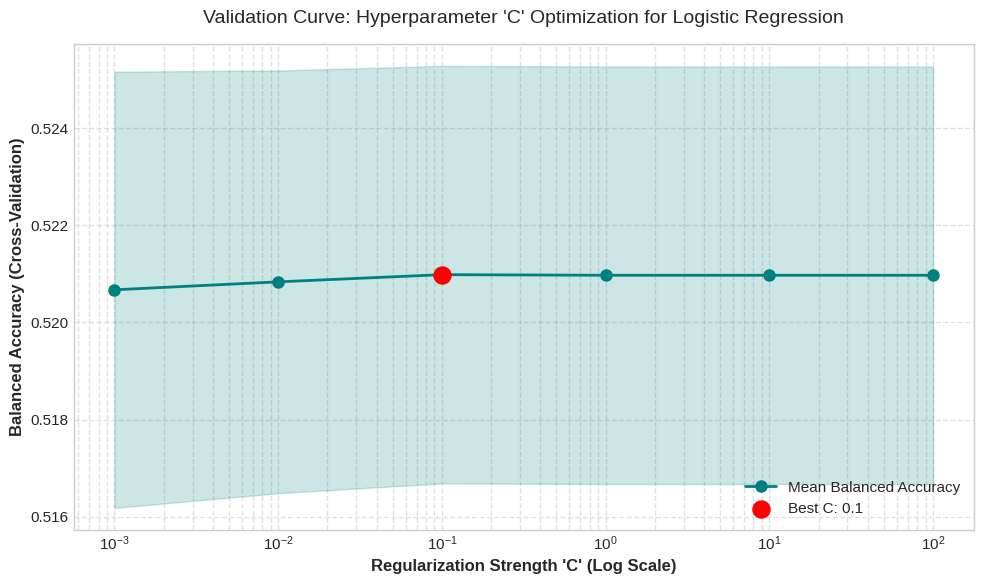

In [ ]:
# Extract detailed results from the Grid Search
c_values = np.array(cv_results['param_model__C'].data, dtype=float)
mean_scores = cv_results['mean_test_score']
std_scores = cv_results['std_test_score']

# --- PLOT CREATION (VALIDATION CURVE) ---
plt.figure(figsize=(10, 6))

plt.plot(c_values, mean_scores, marker='o', linestyle='-', color='teal', linewidth=2, markersize=8, label='Mean Balanced Accuracy')
plt.fill_between(c_values, mean_scores - std_scores, mean_scores + std_scores, alpha=0.2, color='teal')

plt.xscale('log')
plt.xlabel("Regularization Strength 'C' (Log Scale)", fontsize=12, fontweight='bold')
plt.ylabel("Balanced Accuracy (Cross-Validation)", fontsize=12, fontweight='bold')
plt.title("Validation Curve: Hyperparameter 'C' Optimization for Logistic Regression", fontsize=14, pad=15)

plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(loc='lower right', fontsize=11)

best_c = best_hparams['model__C']
plt.scatter(best_c, best_score, color='red', s=150, zorder=5, label=f'Best C: {best_c}')
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()

#**XAI**

Calculating SHAP values


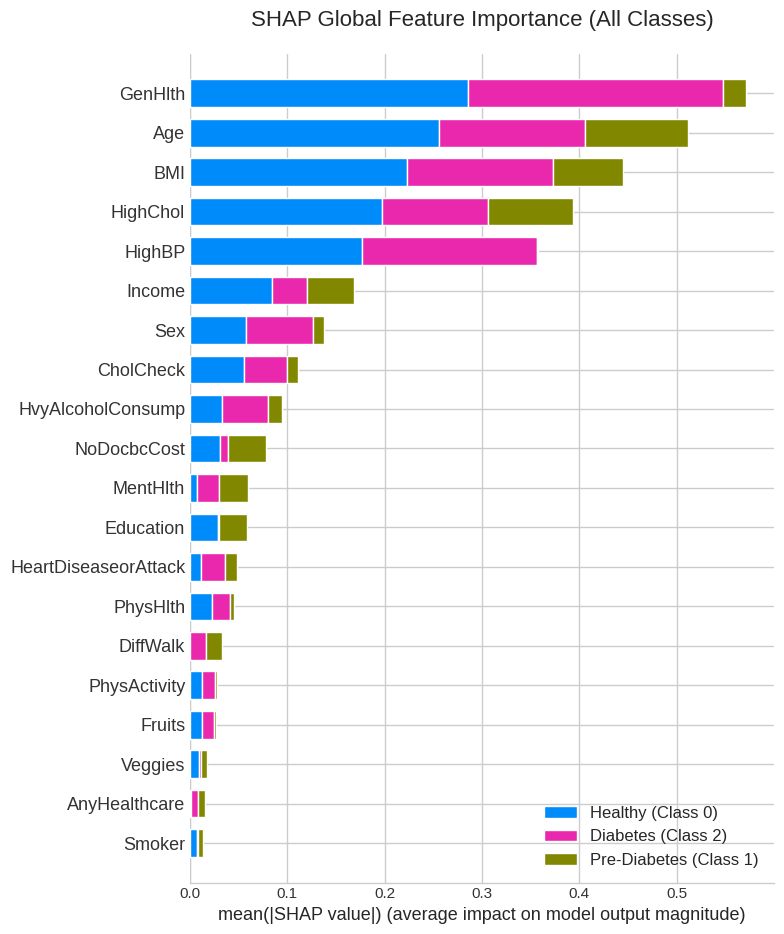

In [ ]:
# 1. Data Sampling
# We sample 3000 instances to ensure fast SHAP computation while maintaining statistical relevance
X_sampled = X.sample(n=3000, random_state=42)

# 2. Initialize the LinearExplainer
# LinearExplainer is highly optimized for models like Logistic Regression
# We pass the trained best_model and the sampled background data
lr_step = best_model.named_steps['model']
scaler_step = best_model.named_steps['scaler']
X_sampled_scaled = pd.DataFrame(scaler_step.transform(X_sampled), columns=X_sampled.columns)

explainer = shap.LinearExplainer(lr_step, X_sampled_scaled)

# 3. Calculate SHAP values
print("Calculating SHAP values")
shap_values = explainer.shap_values(X_sampled_scaled)

# 4. Generate the Global Summary Plot (Bar Chart)
# In multiclass models, shap_values is a list of arrays (one per class)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sampled_scaled,
    plot_type="bar",
    class_names=['Healthy (Class 0)', 'Pre-Diabetes (Class 1)', 'Diabetes (Class 2)'],
    show=False
)

# Customize the plot appearance for the thesis
plt.title("SHAP Global Feature Importance (All Classes)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

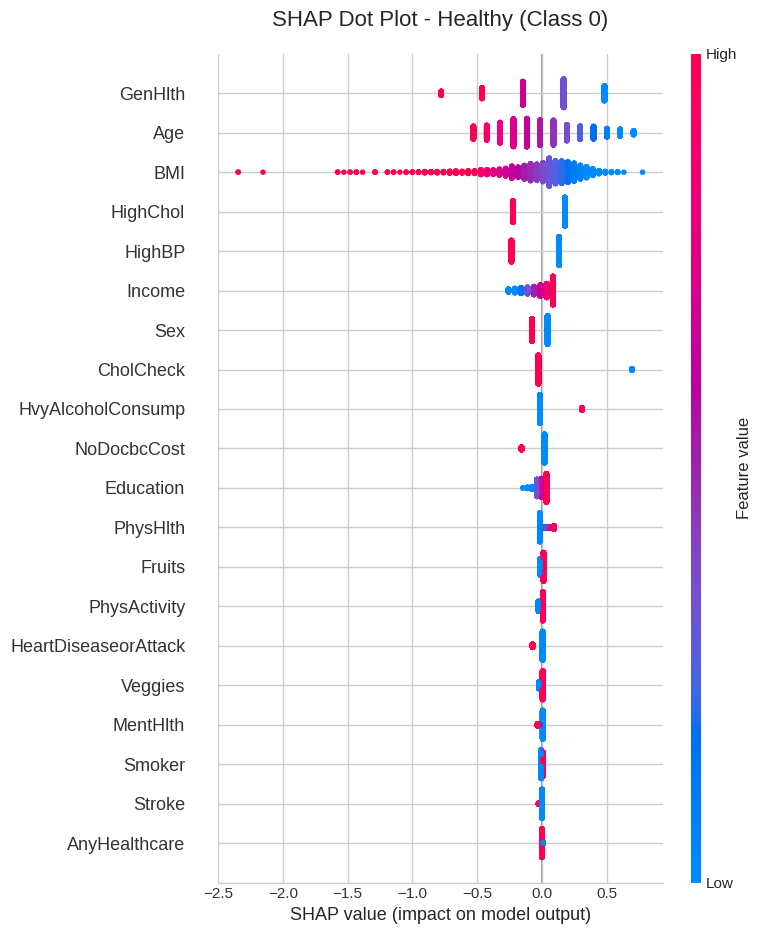

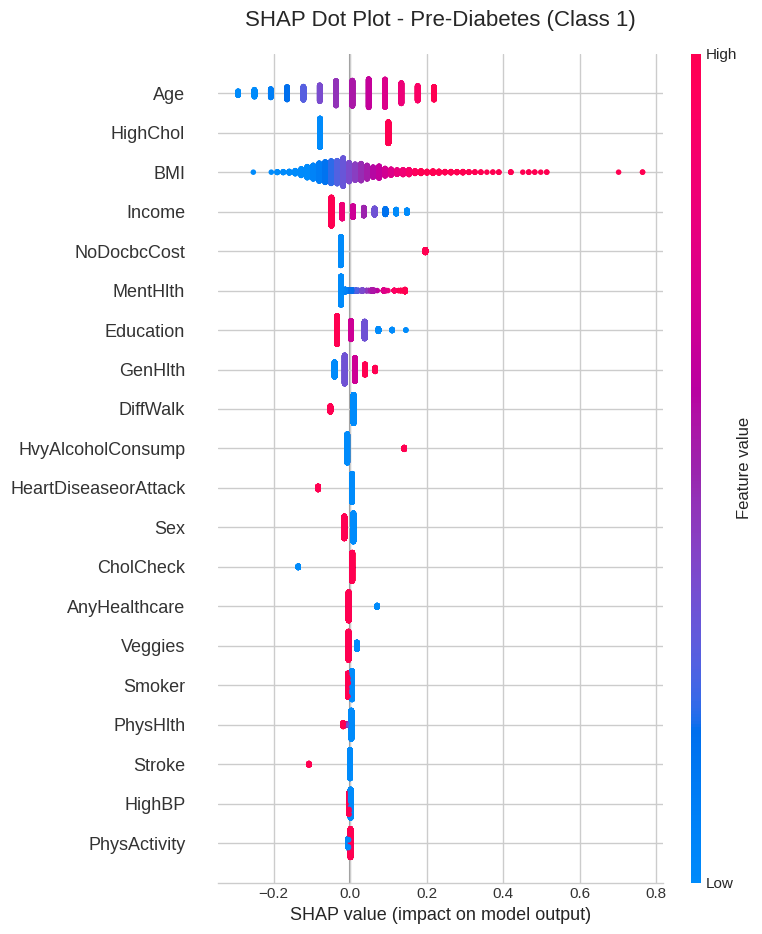

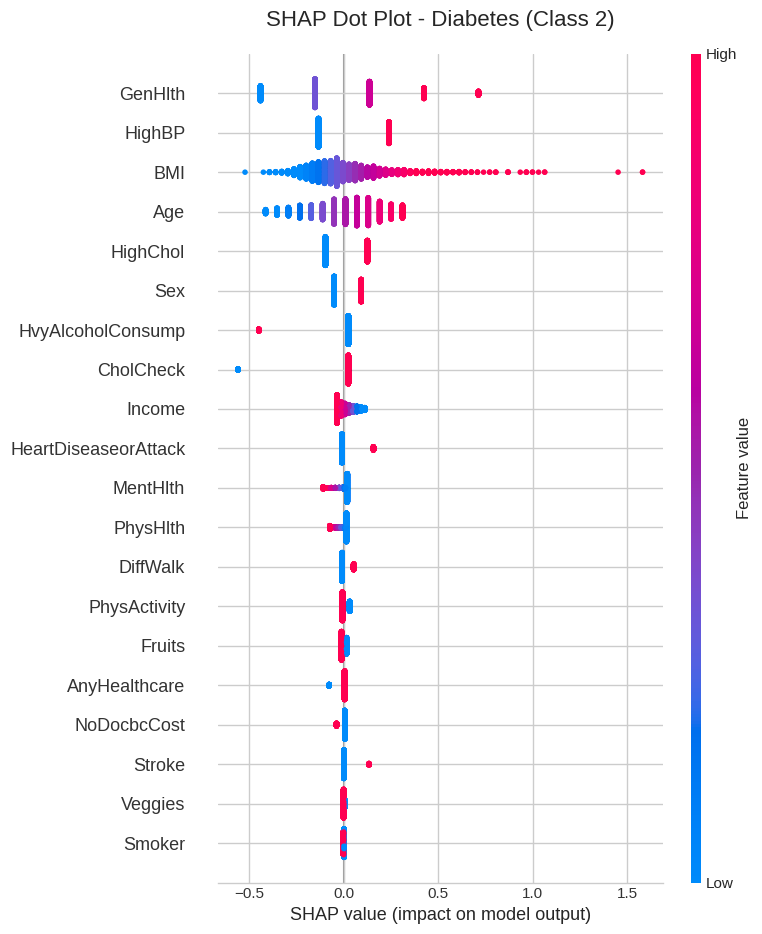

In [ ]:
#1. Safely extract SHAP values ​​for the three classes
if isinstance(shap_values, list):
    shap_class_0 = shap_values[0]
    shap_class_1 = shap_values[1]
    shap_class_2 = shap_values[2]
else:
    shap_class_0 = shap_values[:, :, 0]
    shap_class_1 = shap_values[:, :, 1]
    shap_class_2 = shap_values[:, :, 2]

# 2. SHAP Dot Plot for Class 0 (Healthy)
plt.figure(figsize=(10, 8))
plt.title("SHAP Dot Plot - Healthy (Class 0)", fontsize=16, pad=20)
shap.summary_plot(shap_class_0, X_sampled, show=False)
plt.tight_layout()
plt.show()

# 3. SHAP Dot Plot for Class 1 (Pre-Diabetes)
plt.figure(figsize=(10, 8))
plt.title("SHAP Dot Plot - Pre-Diabetes (Class 1)", fontsize=16, pad=20)
shap.summary_plot(shap_class_1, X_sampled, show=False)
plt.tight_layout()
plt.show()

# 4. SHAP Dot Plot for Class 2 (Diabetes)
plt.figure(figsize=(10, 8))
plt.title("SHAP Dot Plot - Diabetes (Class 2)", fontsize=16, pad=20)
shap.summary_plot(shap_class_2, X_sampled, show=False)
plt.tight_layout()
plt.show()

#**LOCAL ANALYSIS**

Extracted patient indices -> Healthy: 1, Pre-Diab: 64, Diab: 8, False Negative: 10


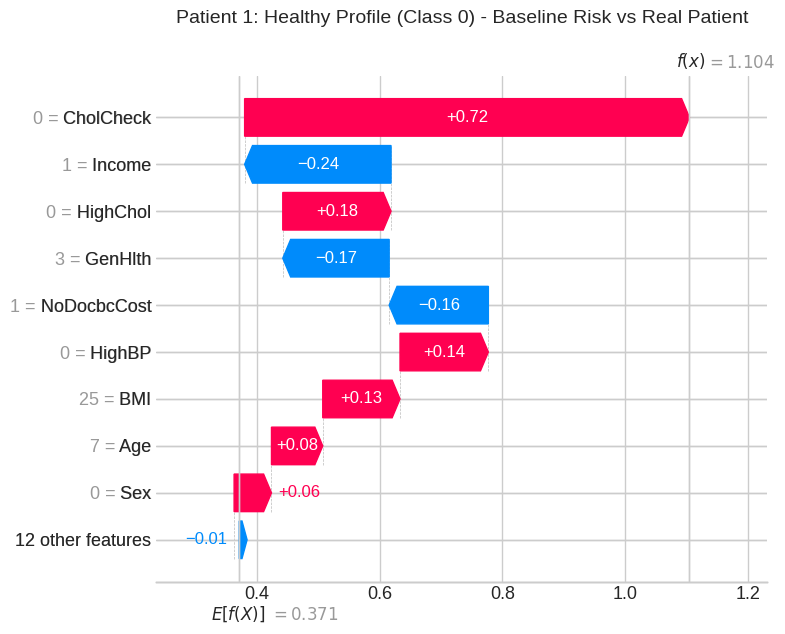

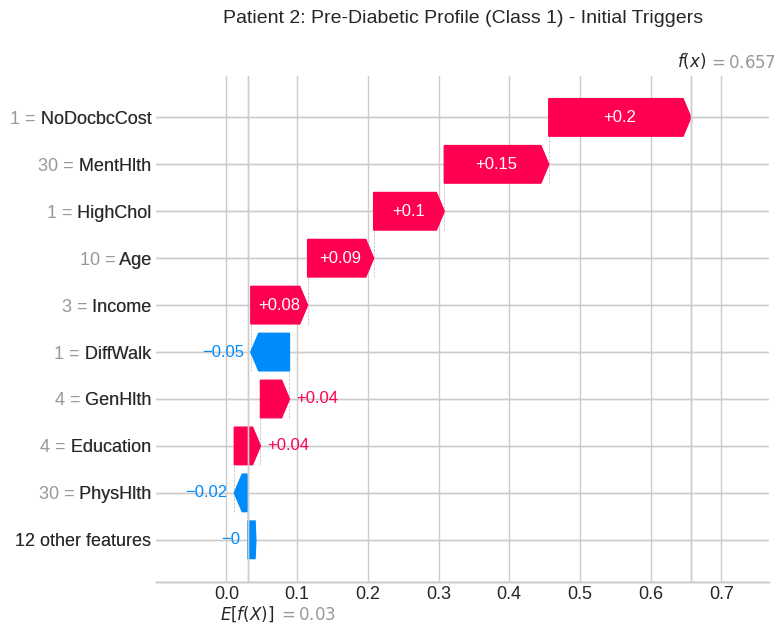

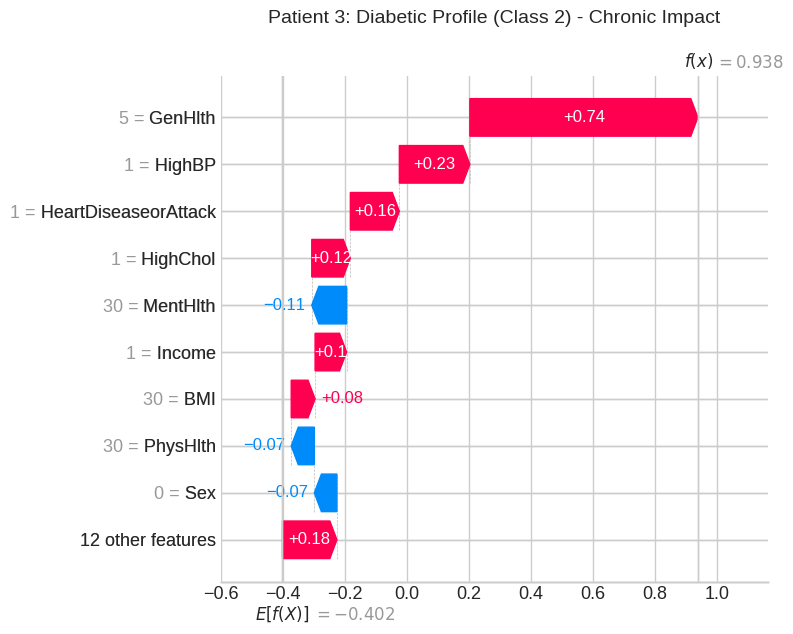

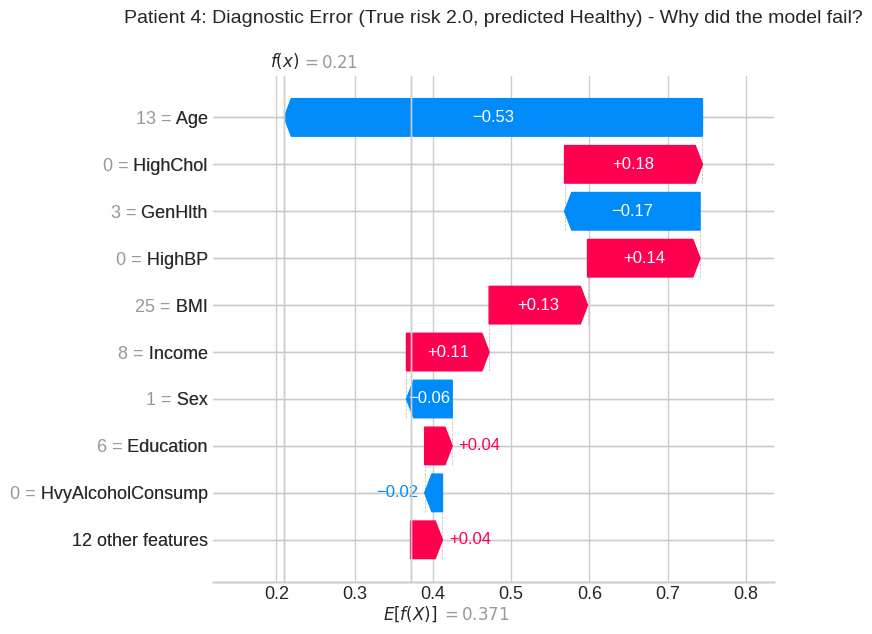

In [ ]:
# 1. SETUP VARIABLES
final_model = best_model

# 2. FIND THE NECESSARY PATIENTS FIRST, THEN BUILD THE SAMPLE
np.random.seed(42)

preds_full = final_model.predict(X)
y_full = y.values

# Find at least one valid index for each scenario (search the entire dataset)
idx_healthy = np.where((y_full == 0) & (preds_full == 0))[0][0]
idx_prediab = np.where((y_full == 1) & (preds_full == 1))[0][0]
idx_diab    = np.where((y_full == 2) & (preds_full == 2))[0][0]
idx_fn      = np.where(((y_full == 1) | (y_full == 2)) & (preds_full == 0))[0][0]

print(f"Extracted patient indices -> Healthy: {idx_healthy}, Pre-Diab: {idx_prediab}, Diab: {idx_diab}, False Negative: {idx_fn}")

# 3. Build X_shap by forcing the 4 patients + random sample
required_indices = [idx_healthy, idx_prediab, idx_diab, idx_fn]
random_indices = list(np.random.choice(len(X), size=2996, replace=False))
all_indices = list(set(required_indices + random_indices))

X_shap = X.iloc[all_indices]

# Scale X_shap for SHAP (the model sees scaled data internally)
lr_final_step = final_model.named_steps['model']
scaler_final_step = final_model.named_steps['scaler']
X_shap_scaled = pd.DataFrame(scaler_final_step.transform(X_shap), columns=X_shap.columns)

# 4. LOCAL SHAP EXPLANATION GENERATION
shap_pos = {orig: pos for pos, orig in enumerate(all_indices)}
pos_healthy = shap_pos[idx_healthy]
pos_prediab = shap_pos[idx_prediab]
pos_diab    = shap_pos[idx_diab]
pos_fn      = shap_pos[idx_fn]

patients_X = X_shap.iloc[[pos_healthy, pos_prediab, pos_diab, pos_fn]]
patients_X_scaled = X_shap_scaled.iloc[[pos_healthy, pos_prediab, pos_diab, pos_fn]]

explainer = shap.LinearExplainer(lr_final_step, X_shap_scaled)
shap_exp = explainer(patients_X_scaled)
shap_exp.data = patients_X.values

# 5. WATERFALL PLOTS
plt.figure(figsize=(10, 6))
plt.title("Patient 1: Healthy Profile (Class 0) - Baseline Risk vs Real Patient", fontsize=14, pad=20)
shap.plots.waterfall(shap_exp[0, :, 0], show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Patient 2: Pre-Diabetic Profile (Class 1) - Initial Triggers", fontsize=14, pad=20)
shap.plots.waterfall(shap_exp[1, :, 1], show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Patient 3: Diabetic Profile (Class 2) - Chronic Impact", fontsize=14, pad=20)
shap.plots.waterfall(shap_exp[2, :, 2], show=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title(f"Patient 4: Diagnostic Error (True risk {y_full[idx_fn]}, predicted Healthy) - Why did the model fail?", fontsize=14, pad=20)
shap.plots.waterfall(shap_exp[3, :, 0], show=False)
plt.tight_layout()
plt.show()
